# 1. Introduction

**Dataset Information**
- This dataset contains customer information from a fictional telco company
- This company provides various services such as streaming, phone, and internet services
<br><br>

**Attribute Information**
- Identifier
  - `customerID` - ID number of the customer

- Target Variable
  - `Churn` - Churn status, whether the customer churned or not

- Demographic information
  - `gender` - Whether the customer is a male or a female
  - `SeniorCitizen` - Whether the customer is a senior citizen or not
  - `Partner` - Whether the customer has a partner or not
  - `Dependents` - Whether the customer has dependents or not

- Customer account information
  - `tenure` - Number of months the customer has used the service
  - `Contract` - The contract term of the customer
  - `PaperlessBilling` - Whether the customer has paperless billing or not
  - `PaymentMethod` - The customer’s payment method
  - `MonthlyCharges` - The amount charged to the customer monthly
  - `TotalCharges` - The total amount charged to the customer
  
- Services that each customer has signed up for
  - `PhoneService` - Whether the customer has a phone service or not
  - `MultipleLines` - Whether the customer has multiple lines or not
  - `InternetService` - Customer’s internet service provider
  - `OnlineSecurity` - Whether the customer has online security or not
  - `OnlineBackup` - Whether the customer has online backup or not
  - `DeviceProtection` - Whether the customer has device protection or not
  - `TechSupport` - Whether the customer has tech support or not
  - `StreamingTV` - Whether the customer has streaming TV or not
  - `StreamingMovies` - Whether the customer has streaming movies or not

**Note:** Since this dataset is using `CamelCase` format for the column names, for this project, I will convert it to `snake_case` format.
<br><br>

**Company Goals**<br>
Increasing profit! But how can we achieve it? Some of the way to increase profit are:
- Acquiring new customers as much as we can
- Retaining existing customers as much as we can
<br><br>

**Problems**
- Companies need to invest (expense costs) to get new customers
- When a customer leaves the service (churns), it indicates a loss of investment
- Cost, time, and effort need to be channelled to replace customers who have left the service
- Acquiring new customers is often more difficult and more expensive than retaining existing customers
- On Hardvard Business Review [page](https://hbr.org/2014/10/the-value-of-keeping-the-right-customers), they said: acquiring a new customer is anywhere from five to 25 times more expensive than retaining an existing one
<br><br>

**Objectives**
- Predict whether customers will continue to use the service or will leave the service
- Understanding the customer behaviors:
  - What keeps customers using the service
  - What makes customers leave the service

# 2. Importing Libraries

In [1]:
!pip install --upgrade matplotlib
!pip install --upgrade seaborn

!pip install xgboost
!pip install lightgbm
!pip install catboost

!pip install inflection
!pip install dython
!pip install shap

In [6]:
# basic
import pandas as pd
import numpy as np

# association between attributes
from dython.nominal import associations

# CamelCase to snake_case format
import inflection

# viz
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.colors import LinearSegmentedColormap
from mpl_toolkits.mplot3d import Axes3D
import seaborn as sns

plt.style.use('fivethirtyeight')
sns.set_style('white')
sns.set_context('notebook', font_scale=1.5, rc={'lines.linewidth':1.5})
# change the maximum width in characters of a column (default: 50)
pd.set_option('display.max_colwidth', None)
# change the display precision for better viz
pd.set_option('display.precision', 3)

# encoding
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import OrdinalEncoder
from sklearn.preprocessing import OneHotEncoder

# scaling
from sklearn.preprocessing import MinMaxScaler
from sklearn.preprocessing import StandardScaler

# oversampling
from imblearn.over_sampling import SMOTE
from imblearn.over_sampling import SMOTENC
from imblearn.over_sampling import ADASYN

# train test split
from sklearn.model_selection import train_test_split

# model
from sklearn.linear_model import LogisticRegression
from sklearn.linear_model import RidgeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import AdaBoostClassifier
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.neural_network import MLPClassifier
from xgboost import XGBClassifier
from xgboost import XGBRFClassifier
from catboost import CatBoostClassifier
from lightgbm import LGBMClassifier
from sklearn.ensemble import VotingClassifier
from sklearn.ensemble import StackingClassifier

# metrics
from sklearn.metrics import accuracy_score
from sklearn.metrics import precision_score
from sklearn.metrics import recall_score
from sklearn.metrics import f1_score
from sklearn.metrics import roc_auc_score
from sklearn.metrics import log_loss
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report
from sklearn.metrics import make_scorer

# model evaluation & tuning hyperparameter
from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import RepeatedStratifiedKFold
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import cross_validate
from sklearn.feature_selection import SelectKBest, RFE, SelectFromModel
from sklearn.feature_selection import chi2, f_classif, mutual_info_classif

# explainable AI
import shap

# 3. Dataset Overview

This is just a basic analysis, such as finding missing values, data types of each column, data variation, etc.
<br><br>

I do this analysis because it seems that this dataset contains no null values. But, actually, it has some null values (clue: on the total charge attribute).

## 3.1. Reading Dataset

In [7]:
path = 'ML_telco_customer_churn_data.csv'

data = pd.read_csv(path)
data.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


## 3.2. Duplicate Values

In [8]:
data.duplicated().sum()

0

This dataset doesn't have any duplicate values. It's a good sign.
<br><br>
Since the `customerID` is not essential, I will drop it.

In [9]:
data.drop('customerID', axis=1, inplace=True)
data.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


## 3.3. Renaming Column Names

Since this dataset is using `CamelCase` format for the column names, I will convert it to `snake_case` format. It's just a personal preference.

In [10]:
# renaming the column
column_list = list(data.columns)

for i, col in enumerate(column_list):
  column_list[i] = inflection.underscore(column_list[i]).replace(' ', '_')

data.columns = column_list
data.head()

,gender,senior_citizen,partner,dependents,tenure,phone_service,multiple_lines,internet_service,online_security,online_backup,device_protection,tech_support,streaming_tv,streaming_movies,contract,paperless_billing,payment_method,monthly_charges,total_charges,churn
0,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


## 3.4. Data Types

### 3.4.1. General Data Type

In [27]:
# Define numerical and categorical columns
numerical_columns = ['tenure', 'monthly_charges', 'total_charges']
categorical_columns = [col for col in data.columns if col not in numerical_columns]

# Create a dictionary to map columns to their general data types
general_data_types = {col: 'numerical' if col in numerical_columns else 'categorical' for col in data.columns}

# Convert the dictionary to a DataFrame
general_data_types_df = pd.DataFrame(general_data_types, index=['general data types'])
general_data_types_df

,gender,senior_citizen,partner,dependents,tenure,phone_service,multiple_lines,internet_service,online_security,online_backup,device_protection,tech_support,streaming_tv,streaming_movies,contract,paperless_billing,payment_method,monthly_charges,total_charges,churn
general data types,categorical,categorical,categorical,categorical,numerical,categorical,categorical,categorical,categorical,categorical,categorical,categorical,categorical,categorical,categorical,categorical,categorical,numerical,numerical,categorical


### 3.4.2. Python Data Type

In [12]:
data_type_python = pd.DataFrame(data.dtypes).T.rename({0:'python data types'})
data_type_python

,gender,senior_citizen,partner,dependents,tenure,phone_service,multiple_lines,internet_service,online_security,online_backup,device_protection,tech_support,streaming_tv,streaming_movies,contract,paperless_billing,payment_method,monthly_charges,total_charges,churn
python data types,object,int64,object,object,int64,object,object,object,object,object,object,object,object,object,object,object,object,float64,object,object


From this output, we can see that the `total_charges` attribute has `object` data type. So, I will change it to numeric.
<br><br>
Before converting to numeric data type, since I had already explored this dataset, let's check the `total_charges` attribute where the `tenure` attribute is `0`.

In [13]:
data.loc[data['tenure'] == 0, ['tenure', 'total_charges', 'churn']]

,tenure,total_charges,churn
488,0,,No
753,0,,No
936,0,,No
1082,0,,No
1340,0,,No
3331,0,,No
3826,0,,No
4380,0,,No
5218,0,,No
6670,0,,No


If you look at the original dataset, if the `tenure` attribute has `0` value, it will have blank value on the `total_charges` attribute. It's reasonable, since they haven't used any services, so they don't have any charges.
<br><br>
But, it's not a null value.

In [106]:
data['total_charges'].isna().sum()

0

It's not null, but a blank space `' '`. So, I will use `errors = coerce` parameter to set the invalid parsing (blank space) as `NaN`.

In [107]:
data['total_charges'] = pd.to_numeric(data['total_charges'], errors='coerce')
data['total_charges'].isna().sum()

0

After converting to numeric data type, our data contains 11 `NaN` values, since some of the value is not a numeric. Then, I will replace the null value with `0`.

In [108]:
data['total_charges'].fillna(0, inplace=True)
data['total_charges'].isna().sum()

0

In [109]:
data['total_charges'] = data['total_charges'].astype(float)
data.dtypes

gender                object
senior_citizen        object
partner               object
dependents            object
tenure                 int64
phone_service         object
multiple_lines        object
internet_service      object
online_security       object
online_backup         object
device_protection     object
tech_support          object
streaming_tv          object
streaming_movies      object
contract              object
paperless_billing     object
payment_method        object
monthly_charges      float64
total_charges        float64
churn                 object
dtype: object

It works. So, I will re-create the dataframe to store the data type of each column.

In [110]:
data_type_python = pd.DataFrame(data.dtypes).T.rename({0:'python data types'})
data_type_python

,gender,senior_citizen,partner,dependents,tenure,phone_service,multiple_lines,internet_service,online_security,online_backup,device_protection,tech_support,streaming_tv,streaming_movies,contract,paperless_billing,payment_method,monthly_charges,total_charges,churn
python data types,object,object,object,object,int64,object,object,object,object,object,object,object,object,object,object,object,object,float64,float64,object


## 3.5. Total Data

In [111]:
data_count = pd.DataFrame(data.count()).T.rename({0:'total data'})
data_count

,gender,senior_citizen,partner,dependents,tenure,phone_service,multiple_lines,internet_service,online_security,online_backup,device_protection,tech_support,streaming_tv,streaming_movies,contract,paperless_billing,payment_method,monthly_charges,total_charges,churn
total data,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043


## 3.6. Null Values

### 3.6.1. Total Null Values

In [112]:
data_null_total = pd.DataFrame(data.isna().sum()).T.rename({0:'total null'})
data_null_total

,gender,senior_citizen,partner,dependents,tenure,phone_service,multiple_lines,internet_service,online_security,online_backup,device_protection,tech_support,streaming_tv,streaming_movies,contract,paperless_billing,payment_method,monthly_charges,total_charges,churn
total null,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0


## 3.7. Data Variation

I will find out the data variation:
- The range of data, for numerical data
- The category variations, for categorical data

### 3.7.1. Numerical Data

This dataset only contains 3 numerical data: `tenure`, `monthly_charges` and `total_charges`.

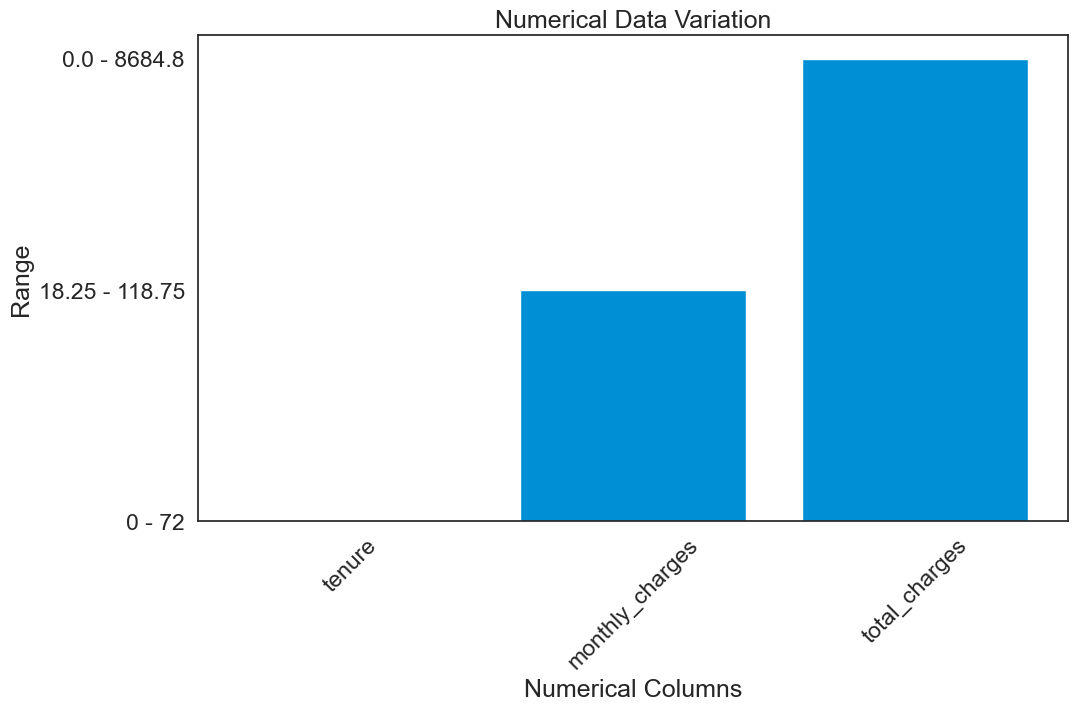

In [114]:
import matplotlib.pyplot as plt

variation_numerical = dict()

for col in numerical_columns:
  tmp = f'{data[col].min()} - {data[col].max()}'
  variation_numerical[col] = tmp

tmp = pd.Series(variation_numerical)
data_variation_numerical = pd.DataFrame(tmp).T.rename({0:'data variation'})

# Plotting the numerical data variation
fig, ax = plt.subplots(figsize=(10, 6))
ax.bar(data_variation_numerical.columns, data_variation_numerical.loc['data variation'])
ax.set_xlabel('Numerical Columns')
ax.set_ylabel('Range')
ax.set_title('Numerical Data Variation')
plt.xticks(rotation=45)
plt.show()

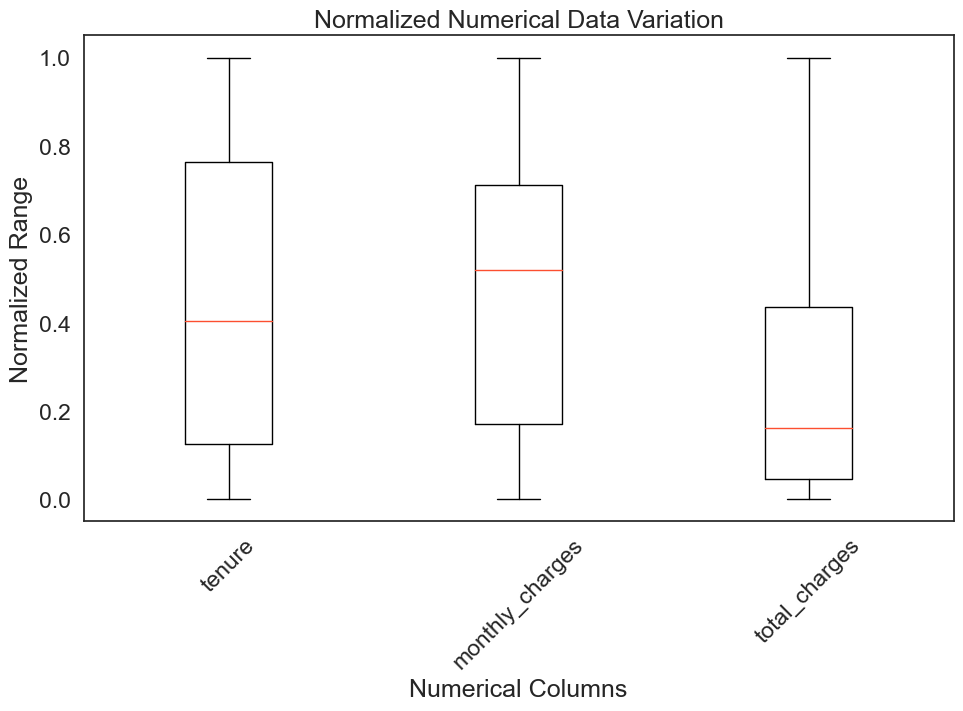

In [115]:
# Normalize the numerical data for better understanding
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()
normalized_data = scaler.fit_transform(data[numerical_columns])
normalized_data = pd.DataFrame(normalized_data, columns=numerical_columns)

# Plotting the normalized numerical data variation
fig, ax = plt.subplots(figsize=(10, 6))
ax.boxplot(normalized_data.values, labels=normalized_data.columns)
ax.set_xlabel('Numerical Columns')
ax.set_ylabel('Normalized Range')
ax.set_title('Normalized Numerical Data Variation')
plt.xticks(rotation=45)
plt.show()


### 3.7.2. Categorical Data

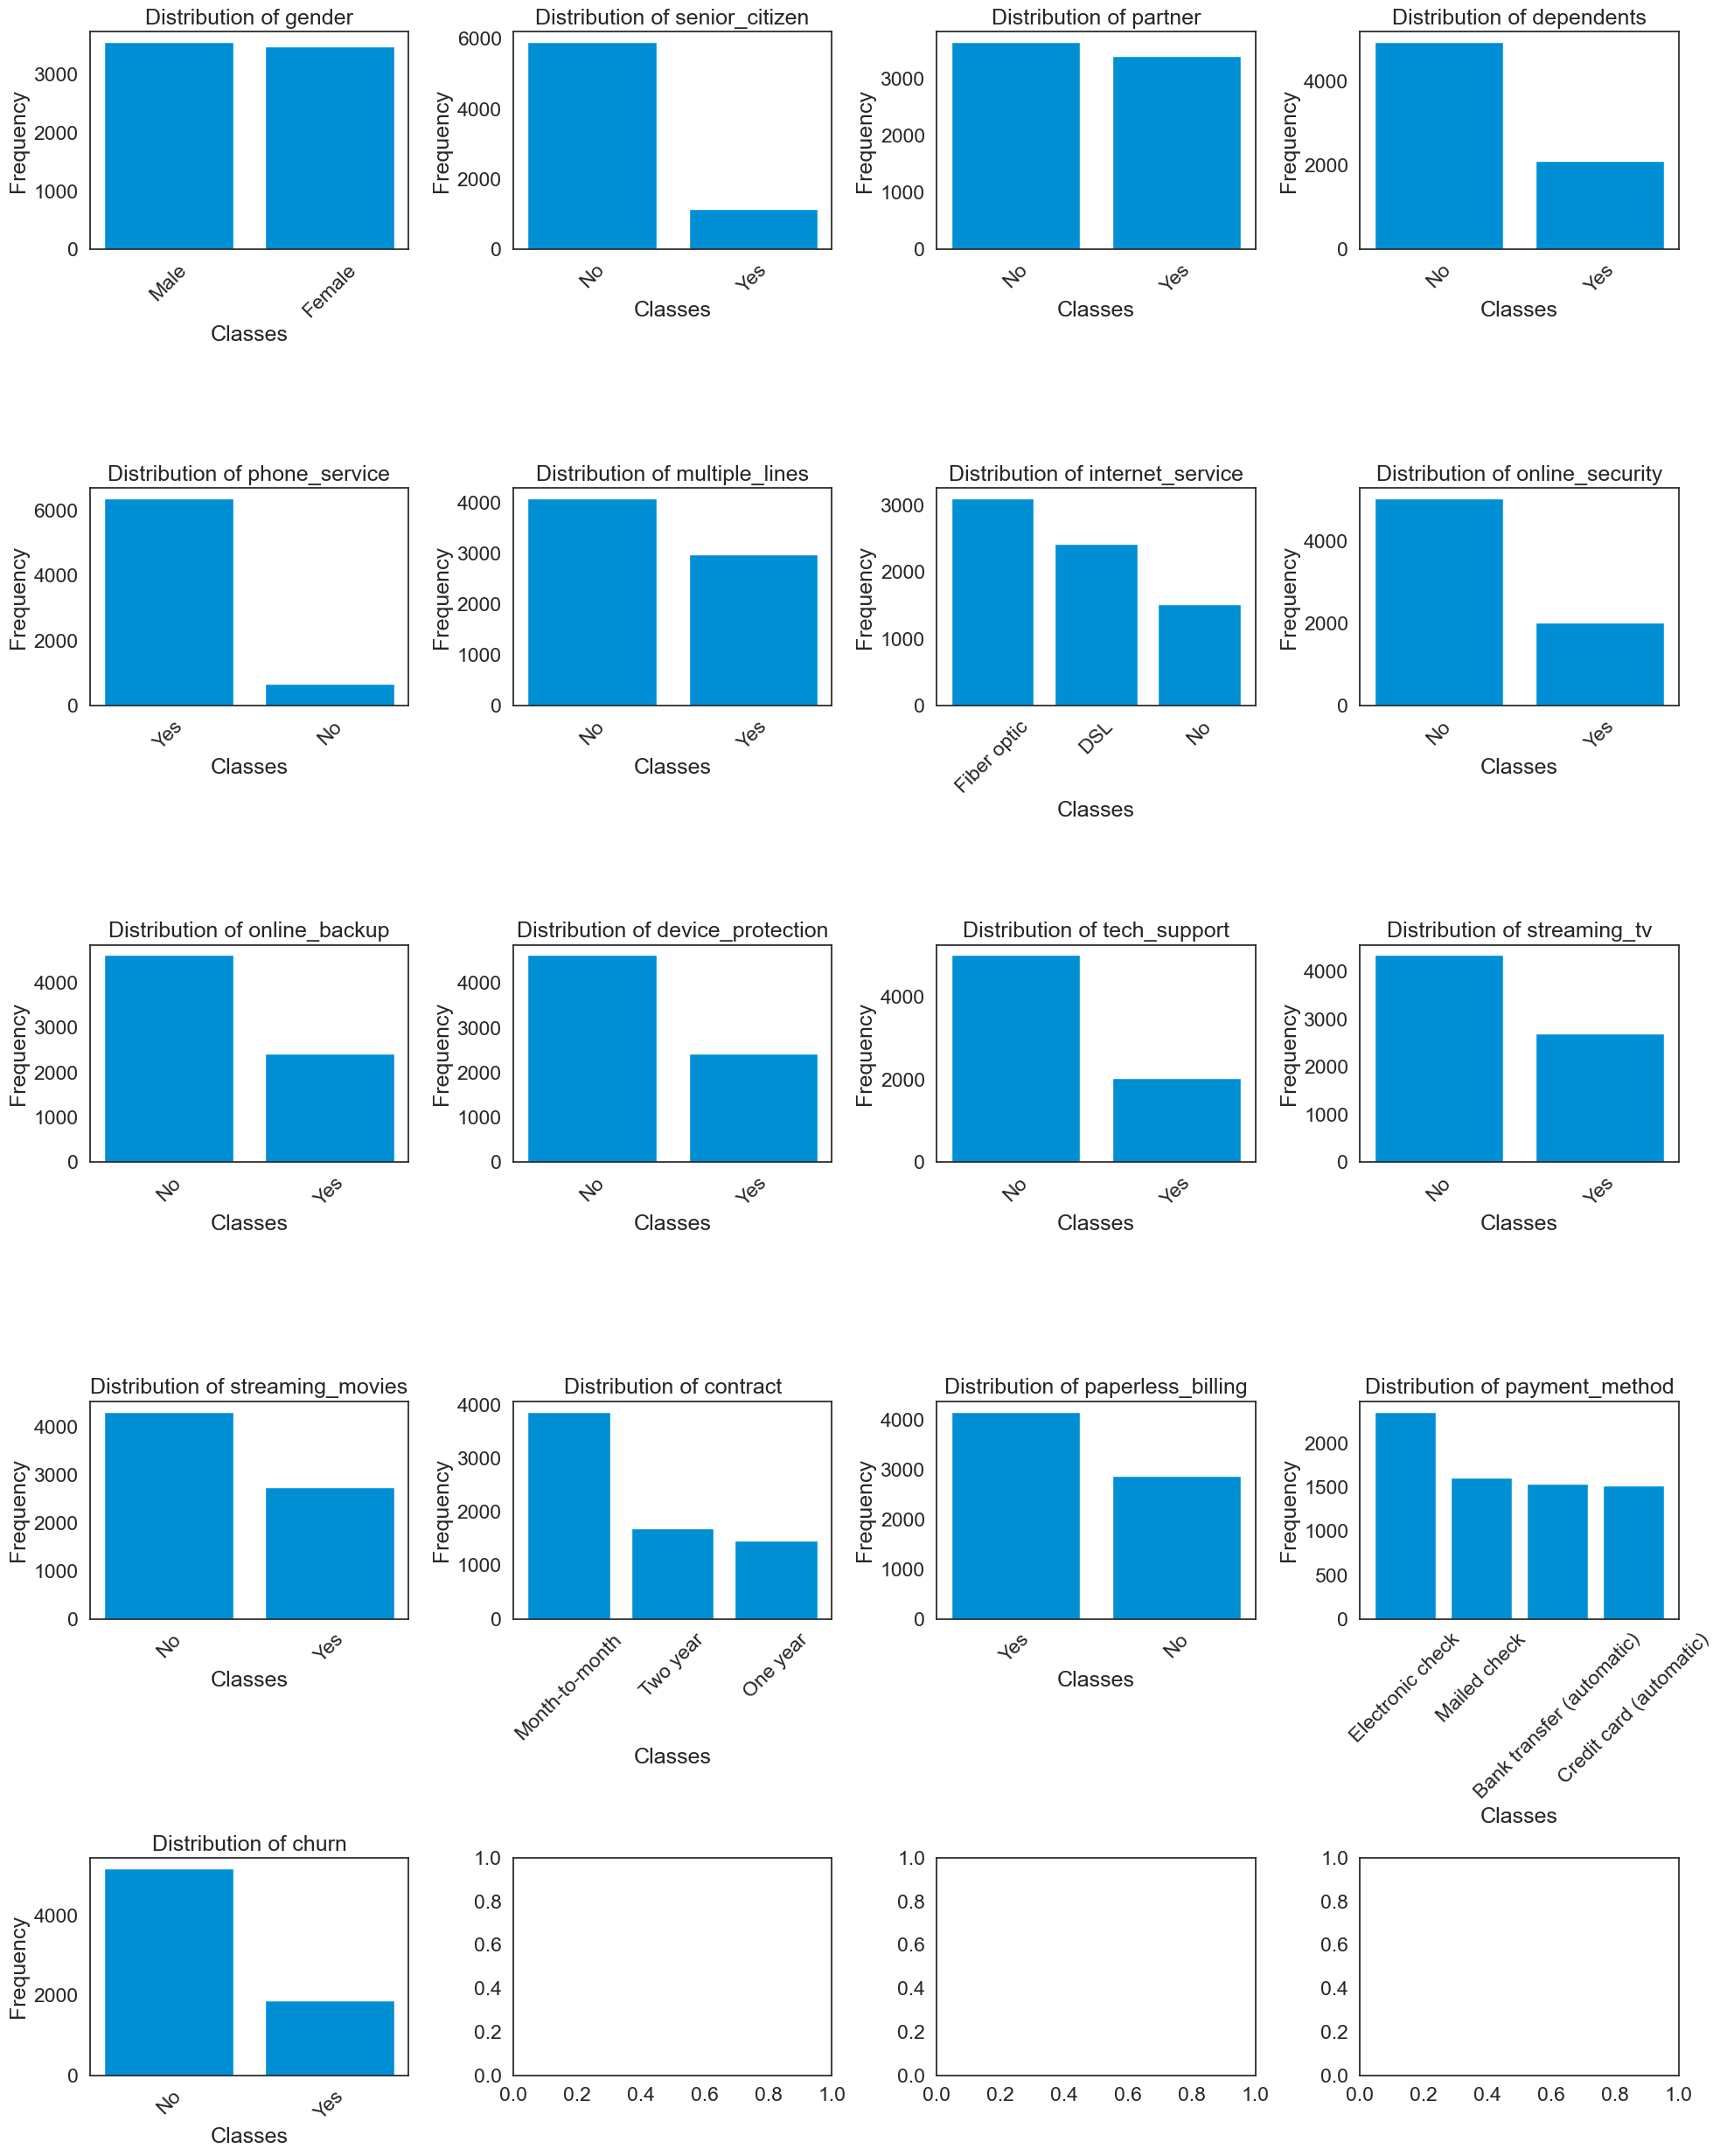

In [120]:
import matplotlib.pyplot as plt

num_cols = len(categorical_columns)
fig, axs = plt.subplots((num_cols + 3) // 4, 4, figsize=(20, 5 * ((num_cols + 3) // 4)))

for i, col in enumerate(categorical_columns):
    value_counts = data[col].value_counts()
    ax = axs[i // 4, i % 4]
    ax.bar(value_counts.index, value_counts.values)
    ax.set_title(f'Distribution of {col}')
    ax.set_xlabel('Classes')
    ax.set_ylabel('Frequency')
    ax.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

### 3.7.3. Overall Data Variation

In [121]:
data_variation = pd.concat([data_variation_numerical, data_variation_categorical], axis=1)
data_variation

,tenure,monthly_charges,total_charges,gender,senior_citizen,partner,dependents,phone_service,multiple_lines,internet_service,online_security,online_backup,device_protection,tech_support,streaming_tv,streaming_movies,contract,paperless_billing,payment_method,churn
data variation,0 - 72,18.25 - 118.75,0.0 - 8684.8,"Female, Male","No, Yes","No, Yes","No, Yes","No, Yes","No, Yes","DSL, Fiber optic, No","No, Yes","No, Yes","No, Yes","No, Yes","No, Yes","No, Yes","Month-to-month, One year, Two year","No, Yes","Bank transfer (automatic), Credit card (automatic), Electronic check, Mailed check","No, Yes"


In [122]:
pd.concat([data_variation_numerical.rename({'data variation':'range'}), data_variation_categorical.rename({'data variation':'variation'})], axis=0).fillna('-').reindex(data.columns, axis=1).T

,range,variation
gender,-,"Female, Male"
senior_citizen,-,"No, Yes"
partner,-,"No, Yes"
dependents,-,"No, Yes"
tenure,0 - 72,-
phone_service,-,"No, Yes"
multiple_lines,-,"No, Yes"
internet_service,-,"DSL, Fiber optic, No"
online_security,-,"No, Yes"
online_backup,-,"No, Yes"


### 3.7.4. Redundant Values

Let's take a look at the `multiple_lines` attribute. It has a category of `No phone service`. It's a redundant category, because if the customer doesn't have phone service (`phone_service = No`), then they can't have multiple lines service, which requires phone service.
<br><br>
This also applies to the `online_security`, `online_backup`, `device_protection`, `tech_support`, `streaming_tv`, and `streaming_movies` attributes. These services require internet service.
<br><br>
My solution is simply replace these categories to `No`. This solution is also used to avoid multicollinearity and reduce the dataset dimension (after one-hot encoding, I will cover it on the data preprocessing section)

In [123]:
# replace redundant values
data.replace({'No phone service':'No',
            'No internet service':'No'},
            inplace=True)

data['senior_citizen'].replace({0:'No',
                                1:'Yes'},
                                inplace=True)

In [124]:
variation_categorical = dict()

for col in categorical_columns:
  tmp = data[col].unique().tolist()
  tmp.sort()
  variation_categorical[col] = ', '.join(str(item) for item in tmp)

tmp = pd.Series(variation_categorical)
data_variation_categorical = pd.DataFrame(tmp).T.rename({0:'data variation'})

data_variation = pd.concat([data_variation_numerical, data_variation_categorical], axis=1)
data_variation

,tenure,monthly_charges,total_charges,gender,senior_citizen,partner,dependents,phone_service,multiple_lines,internet_service,online_security,online_backup,device_protection,tech_support,streaming_tv,streaming_movies,contract,paperless_billing,payment_method,churn
data variation,0 - 72,18.25 - 118.75,0.0 - 8684.8,"Female, Male","No, Yes","No, Yes","No, Yes","No, Yes","No, Yes","DSL, Fiber optic, No","No, Yes","No, Yes","No, Yes","No, Yes","No, Yes","No, Yes","Month-to-month, One year, Two year","No, Yes","Bank transfer (automatic), Credit card (automatic), Electronic check, Mailed check","No, Yes"


In [125]:
pd.concat([data_variation_numerical.rename({'data variation':'range'}), data_variation_categorical.rename({'data variation':'variation'})], axis=0).fillna('-').reindex(data.columns, axis=1).T

,range,variation
gender,-,"Female, Male"
senior_citizen,-,"No, Yes"
partner,-,"No, Yes"
dependents,-,"No, Yes"
tenure,0 - 72,-
phone_service,-,"No, Yes"
multiple_lines,-,"No, Yes"
internet_service,-,"DSL, Fiber optic, No"
online_security,-,"No, Yes"
online_backup,-,"No, Yes"


## 3.8. Summary of Dataset Info

In [36]:
data_type_general = dict()

for col in data.columns:
  if col in numerical_columns:
    data_type_general[col] = 'numerical'
  else:
    data_type_general[col] = 'categorical'

tmp = pd.Series(data_type_general)
data_type_general = pd.DataFrame(tmp).T.rename({0:'general data types'})
data_type_general

,gender,senior_citizen,partner,dependents,tenure,phone_service,multiple_lines,internet_service,online_security,online_backup,device_protection,tech_support,streaming_tv,streaming_movies,contract,paperless_billing,payment_method,monthly_charges,total_charges,churn
general data types,categorical,categorical,categorical,categorical,numerical,categorical,categorical,categorical,categorical,categorical,categorical,categorical,categorical,categorical,categorical,categorical,categorical,numerical,numerical,categorical


In [37]:
data_null_percentage = pd.DataFrame(100*data.isna().sum()/data.shape[0]).T.rename({0:'percentage null'})
data_null_percentage

,gender,senior_citizen,partner,dependents,tenure,phone_service,multiple_lines,internet_service,online_security,online_backup,device_protection,tech_support,streaming_tv,streaming_movies,contract,paperless_billing,payment_method,monthly_charges,total_charges,churn
percentage null,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [38]:
data_info = pd.concat([data_type_general, data_type_python,
                       data_count, data_null_total,
                       data_null_percentage.round(2), data_variation],
                      axis=0)

data_info = data_info.reindex(data.columns, axis=1)
data_info

,gender,senior_citizen,partner,dependents,tenure,phone_service,multiple_lines,internet_service,online_security,online_backup,device_protection,tech_support,streaming_tv,streaming_movies,contract,paperless_billing,payment_method,monthly_charges,total_charges,churn
general data types,categorical,categorical,categorical,categorical,numerical,categorical,categorical,categorical,categorical,categorical,categorical,categorical,categorical,categorical,categorical,categorical,categorical,numerical,numerical,categorical
python data types,object,int64,object,object,int64,object,object,object,object,object,object,object,object,object,object,object,object,float64,float64,object
total data,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043
total null,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
percentage null,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
data variation,"Female, Male","No, Yes","No, Yes","No, Yes",0 - 72,"No, Yes","No, Yes","DSL, Fiber optic, No","No, Yes","No, Yes","No, Yes","No, Yes","No, Yes","No, Yes","Month-to-month, One year, Two year","No, Yes","Bank transfer (automatic), Credit card (automatic), Electronic check, Mailed check",18.25 - 118.75,0.0 - 8684.8,"No, Yes"


# 4. Exploratory Data Analysis

In [126]:
# numerical
column_numerical = ['tenure', 'monthly_charges', 'total_charges']

# categorical
column_categorical = list(data.columns)
column_categorical.remove('tenure')
column_categorical.remove('monthly_charges')
column_categorical.remove('total_charges')

# only contains input features
column_categorical.remove('churn')

In [127]:
data_viz = data.copy()
data_viz.loc[:,'churn'] = data_viz.loc[:, 'churn'].apply(lambda x: 'churn' if x == 'Yes' else 'retain')

## 4.1. Visualization Function

In [41]:
def stacked_bar_plot(data, x, y, orient='horizontal', ax=None, show=True):
  # create axis if not present
  if ax == None:
    _, ax = plt.subplots(figsize=(8,6))
  
  # create crosstab based on the input data
  crosstab = pd.crosstab(index=data[x], columns=data[y], normalize='index')
  crosstab = crosstab.reindex(['retain', 'churn'], axis=1)

  # visualize stacked barplot
  if orient == 'vertical':
    # order in descending (the highest value on the left)
    crosstab = crosstab.sort_values('churn', ascending=False)
    crosstab.plot(kind='bar', stacked=True, ax=ax)

    # add percentage label
    for i, index in enumerate(crosstab.index):
        for (proportion, y_loc) in zip(crosstab.loc[index], crosstab.loc[index].cumsum()):
          ax.text(x=i,
                  y=(y_loc - proportion) + (proportion / 2),
                  s=f'{proportion*100:.1f}%',
                  color='white',
                  fontsize=14,
                  fontweight='bold',
                  horizontalalignment='center',
                  verticalalignment='center')
    # remove tick labels
    ax.set_yticklabels([])
  else: # default is horizontal bar plot, even if the orient input is an arbitrary value
    # orient in ascending (the highest value on the top)
    crosstab = crosstab.sort_values('churn', ascending=True)
    crosstab.plot(kind='barh', stacked=True, ax=ax)

    # add percentage label
    for i, index in enumerate(crosstab.index):
        for (proportion, x_loc) in zip(crosstab.loc[index], crosstab.loc[index].cumsum()):
          ax.text(y=i,
                  x=(x_loc - proportion) + (proportion / 2),
                  s=f'{proportion*100:.1f}%',
                  color='white',
                  fontsize=14,
                  fontweight='bold',
                  horizontalalignment='center',
                  verticalalignment='center')
    # remove tick labels
    ax.set_xticklabels([])

  x_titleize = inflection.titleize(x)
  ax.set_title(f'Customer Churn Probability by {x_titleize}')      
  ax.set_xlabel('')
  ax.set_ylabel('')
  ax.legend(loc='center left', bbox_to_anchor=(1, 0.5), title='', frameon=False)
  # ax.legend(loc='lower center', bbox_to_anchor=(0.5, 1), title='', ncol=2, frameon=False)
  sns.despine(left=True, bottom=True)

  if show:
    plt.show()

## 4.2. Target Distribution

In [43]:
import plotly.express as px

pie_data = data_viz['churn'].value_counts(normalize=True).reset_index()
pie_data.columns = ['churn', 'percentage']
pie_data['percentage'] = pie_data['percentage'] * 100

fig = px.pie(pie_data, values='percentage', names='churn', 
             title='Customer Churn Distribution', 
             color_discrete_sequence=px.colors.sequential.RdBu,
             hole=0.3)

fig.update_traces(textposition='inside', textinfo='percent+label', 
                  marker=dict(line=dict(color='#000000', width=2)))

fig.show()

As we can see, 27% of customers leave the services. Technically speaking, this dataset is an imbalanced dataset.

## 4.3. Why Did It Happen?

There are so many factors, but not all attributes have a strong relationship with customer's churn status.

In [129]:
categorical_columns = ['gender', 'senior_citizen', 'partner', 'dependents', 'phone_service', 
                       'multiple_lines', 'internet_service', 'online_security', 'online_backup', 
                       'device_protection', 'tech_support', 'streaming_tv', 'streaming_movies', 
                       'contract', 'paperless_billing', 'payment_method']

for col in categorical_columns:
    pie_data = data_viz[col].value_counts(normalize=True).reset_index()
    pie_data.columns = [col, 'percentage']
    pie_data['percentage'] = pie_data['percentage'] * 100

    fig = px.pie(pie_data, values='percentage', names=col, 
                 title=f'Customer Churn Distribution by {col.title().replace("_", " ")}', 
                 color_discrete_sequence=px.colors.sequential.RdBu,
                 hole=0.3)

    fig.update_traces(textposition='inside', textinfo='percent+label', 
                      marker=dict(line=dict(color='#000000', width=2)))

    fig.show()

Both males and females almost have the same probability to churn. We can say that customer’s gender has no relationship with their churn status.

In [49]:
pie_data = data_viz['senior_citizen'].value_counts(normalize=True).reset_index()
pie_data.columns = ['senior_citizen', 'percentage']
pie_data['percentage'] = pie_data['percentage'] * 100

fig = px.pie(pie_data, values='percentage', names='senior_citizen', 
             title='Customer Churn Distribution by Senior Citizen', 
             color_discrete_sequence=px.colors.sequential.RdBu,
             hole=0.3)

fig.update_traces(textposition='inside', textinfo='percent+label', 
                  marker=dict(line=dict(color='#000000', width=2)))

fig.show()

Senior citizens have a higher probability of churn than younger citizens. We can say this attribute has a relationship with churn status.

## 4.4. Churn Probability

### 4.4.1. All Categories

C:\Users\muzny\AppData\Local\Temp\ipykernel_17492\3680678282.py:25: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.




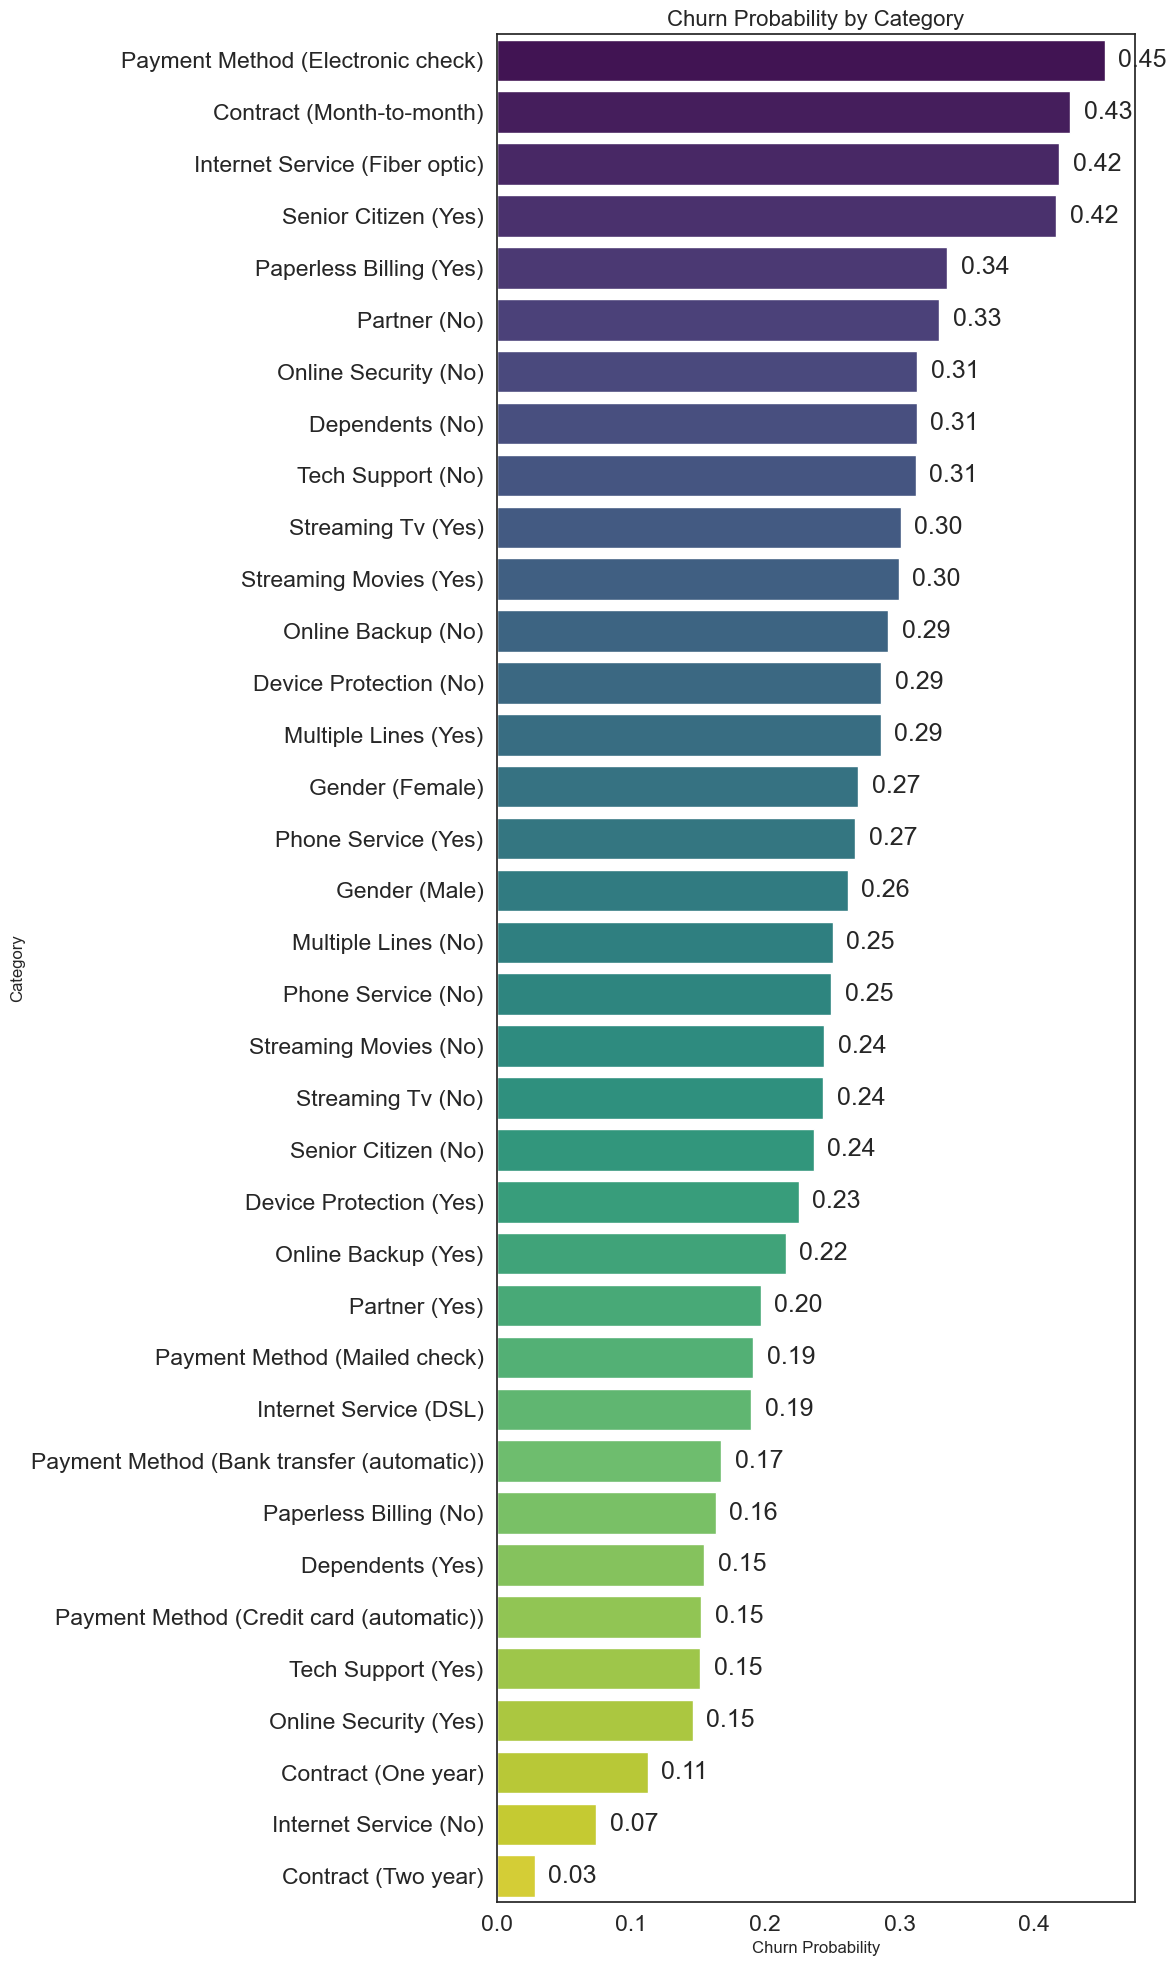

In [130]:
columns = data_viz['churn']

attr_crosstab = pd.DataFrame()

for col in column_categorical:
  # create crosstab for each attribute
  index = data_viz[col]
  ct = pd.crosstab(index=index, columns=columns, normalize='index', colnames=[None]).reset_index()

  # add prefix to each category
  # format: column name (category)
  col_titleize = inflection.titleize(col)
  ct[col] = ct[col].apply(lambda x: f'{col_titleize} ({x})')

  # rename the column
  ct.rename(columns={col:'attribute'}, inplace=True)

  # create a single dataframe
  attr_crosstab = pd.concat([attr_crosstab, ct])

attr_crosstab = attr_crosstab.sort_values('churn', ascending=False).reset_index(drop=True)

# Create a horizontal bar chart instead of using style.background_gradient()
plt.figure(figsize=(12, 20))
chart = sns.barplot(x='churn', y='attribute', data=attr_crosstab, palette='viridis')
chart.set_title('Churn Probability by Category', fontsize=16)
chart.set_xlabel('Churn Probability', fontsize=12)
chart.set_ylabel('Category', fontsize=12)

# Add value labels to the bars
for i, v in enumerate(attr_crosstab['churn']):
    chart.text(v + 0.01, i, f'{v:.2f}', va='center')

plt.tight_layout()
plt.show()

# Still return the styled dataframe for reference
# attr_crosstab.style.background_gradient()

### 4.4.2. Top 5 Churn Probability

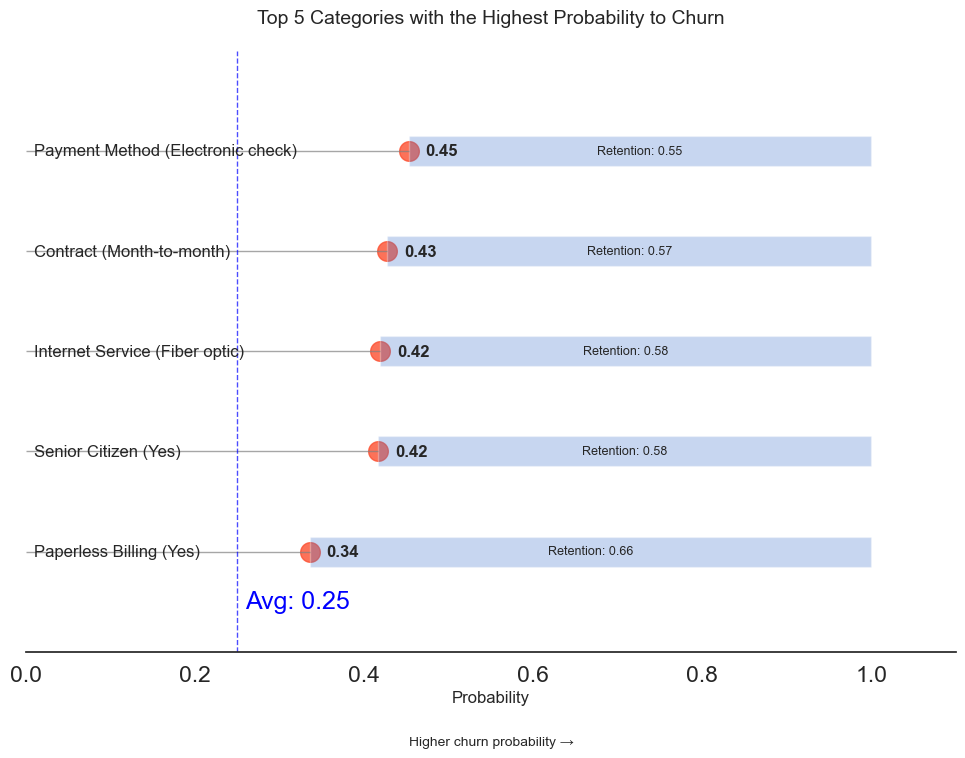

In [131]:
# Create a more informative horizontal lollipop chart
fig, ax = plt.subplots(figsize=(10, 8))

# Get top 5 categories with highest churn probability
top5 = attr_crosstab.iloc[:5].sort_values('churn')

# Create the lollipop chart
ax.hlines(y=range(len(top5)), xmin=0, xmax=top5['churn'], color='gray', alpha=0.7, linewidth=1)
ax.scatter(top5['churn'], range(len(top5)), color='#FC4F30', s=200, alpha=0.8)

# Add category names and percentages
for i, (idx, row) in enumerate(top5.iterrows()):
    ax.text(0.01, i, row['attribute'], va='center', ha='left', fontsize=12)
    ax.text(row['churn'] + 0.02, i, f"{row['churn']:.2f}", va='center', ha='left', fontsize=12, fontweight='bold')

# Add a vertical line for the average churn rate
avg_churn = attr_crosstab['churn'].mean()
ax.axvline(x=avg_churn, color='blue', linestyle='--', alpha=0.7, linewidth=1)
ax.text(avg_churn + 0.01, -0.5, f'Avg: {avg_churn:.2f}', va='center', color='blue')

# Add a complementary bar showing retention rate (1-churn)
for i, (idx, row) in enumerate(top5.iterrows()):
    retention = 1 - row['churn']
    ax.barh(i, retention, left=row['churn'], height=0.3, color='#4878D0', alpha=0.3)
    ax.text(row['churn'] + retention/2, i, f"Retention: {retention:.2f}", va='center', ha='center', fontsize=9)

# Customize the plot
ax.set_title('Top 5 Categories with the Highest Probability to Churn', fontsize=14, pad=20)
ax.set_xlabel('Probability', fontsize=12)
ax.set_xlim(0, 1.1)
ax.set_yticks([])
ax.set_ylim(-1, len(top5))

# Add annotations
ax.text(0.5, -0.15, 'Higher churn probability →', ha='center', va='center', transform=ax.transAxes, fontsize=10)

# Remove spines
sns.despine(left=True, bottom=False)
plt.tight_layout()
plt.show()

### 4.4.3. Top 5 Retain Probability

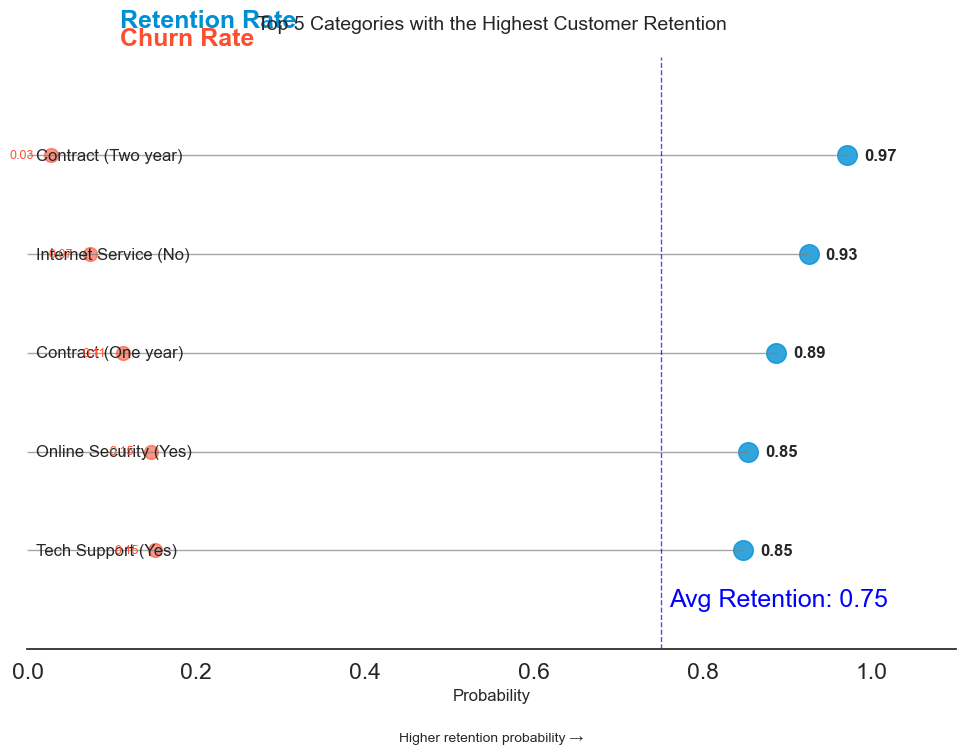

In [55]:
# Create a more informative lollipop chart for retention
fig, ax = plt.subplots(figsize=(10, 8))

# Get bottom 5 categories with lowest churn probability (highest retention)
bottom5 = attr_crosstab.iloc[-5:].sort_values('churn', ascending=False)

# Calculate retention rate
bottom5['retention'] = 1 - bottom5['churn']

# Create the lollipop chart
ax.hlines(y=range(len(bottom5)), xmin=0, xmax=bottom5['retention'], color='gray', alpha=0.7, linewidth=1)
ax.scatter(bottom5['retention'], range(len(bottom5)), color='#008FD5', s=200, alpha=0.8)

# Add category names and percentages
for i, (idx, row) in enumerate(bottom5.iterrows()):
    ax.text(0.01, i, row['attribute'], va='center', ha='left', fontsize=12)
    ax.text(row['retention'] + 0.02, i, f"{row['retention']:.2f}", va='center', ha='left', fontsize=12, fontweight='bold')
    
    # Add small red dot for churn rate
    ax.scatter(row['churn'], i, color='#FC4F30', s=100, alpha=0.6)
    ax.text(row['churn'] - 0.02, i, f"{row['churn']:.2f}", va='center', ha='right', fontsize=9, color='#FC4F30')

# Add a vertical line for the average retention rate
avg_retention = 1 - attr_crosstab['churn'].mean()
ax.axvline(x=avg_retention, color='blue', linestyle='--', alpha=0.7, linewidth=1)
ax.text(avg_retention + 0.01, -0.5, f'Avg Retention: {avg_retention:.2f}', va='center', color='blue')

# Customize the plot
ax.set_title('Top 5 Categories with the Highest Customer Retention', fontsize=14, pad=20)
ax.set_xlabel('Probability', fontsize=12)
ax.set_xlim(0, 1.1)
ax.set_yticks([])
ax.set_ylim(-1, len(bottom5))

# Add annotations
ax.text(0.5, -0.15, 'Higher retention probability →', ha='center', va='center', transform=ax.transAxes, fontsize=10)
ax.text(0.1, 1.05, 'Retention Rate', color='#008FD5', fontweight='bold', transform=ax.transAxes)
ax.text(0.1, 1.02, 'Churn Rate', color='#FC4F30', fontweight='bold', transform=ax.transAxes)

# Remove spines
sns.despine(left=True, bottom=False)
plt.tight_layout()
plt.show()

## 4.5. How About The Numerical Data?

### 4.5.1. Churn Probability by Tenure

C:\Users\muzny\AppData\Local\Temp\ipykernel_17492\1767263928.py:4: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.




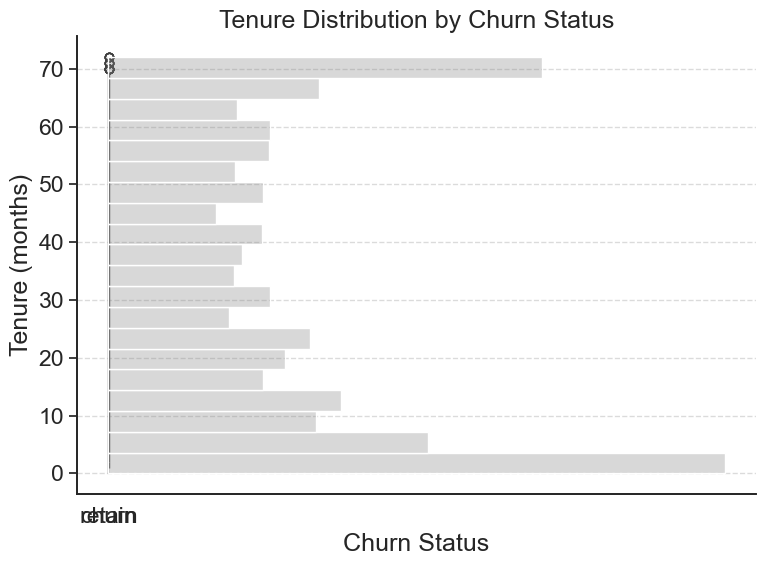

In [63]:
fig, ax = plt.subplots(figsize=(8, 6))

# Create boxplot to show tenure distribution by churn status
sns.boxplot(data=data_viz, x='churn', y='tenure', ax=ax, palette=['#008FD5', '#FC4F30'], width=0.5)

# Add a histogram on the right side to show overall tenure distribution
ax2 = ax.twinx()
sns.histplot(data=data_viz, y='tenure', ax=ax2, color='gray', alpha=0.3, bins=20)
ax2.set_ylabel('')
ax2.set_yticks([])

# Customize the plot
ax.set_xlabel('Churn Status')
ax.set_ylabel('Tenure (months)')
ax.set_title('Tenure Distribution by Churn Status')

# Add grid lines for better readability
ax.grid(True, axis='y', linestyle='--', alpha=0.7)

# Remove unnecessary spines
sns.despine(left=False, bottom=False)

plt.tight_layout()
plt.show()

It has a clear trend!<br>
I can say, tenure has a negative correlation with the probability of churn.
<br><br>
We can look at the short tenure (let's say the first 5 month), the probability of churn is quite high. I suspect that this is the time for new customers to try the services. Then, they consider whether they will continue to use the services or not.

### 4.5.2. Tenure by Contract Type

C:\Users\muzny\AppData\Local\Temp\ipykernel_17492\998875677.py:4: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.




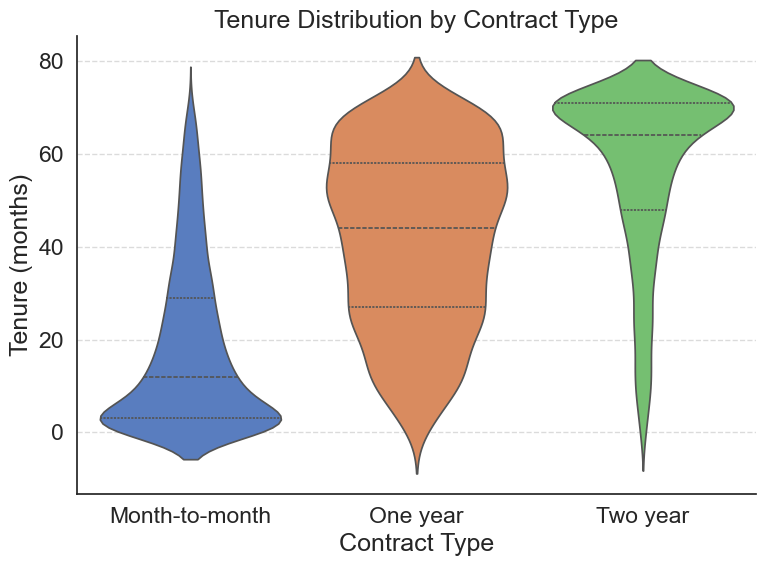

In [64]:
fig, ax = plt.subplots(figsize=(8, 6))

# Create a violin plot to show the distribution of tenure by contract type
sns.violinplot(data=data_viz, x='contract', y='tenure', ax=ax, palette='muted', inner='quartile')

# Customize the plot
ax.set_xlabel('Contract Type')
ax.set_ylabel('Tenure (months)')
ax.set_title('Tenure Distribution by Contract Type')

# Add grid lines for better readability
ax.grid(True, axis='y', linestyle='--', alpha=0.7)

# Remove unnecessary spines
sns.despine(left=False, bottom=False)

plt.tight_layout()
plt.show()

In the previous section (Churn Probability), I found that month-to-month contracts have a fairly high chance of churn. Morover, it's the second category with the highest probability to churn.
<br><br>
Here, I try to analyze the distribution of tenure based on the type of contract.
<br><br>
It can be seen that customers who take month-to-month contracts mostly have short tenures. There are around 25% of customers who have a month-to-month contract and tenure is less than 5 months.
<br><br>
This could be a new assumption:
- Short tenure means that the customer is still new to the service
- New customers have a tendency to take the shortest contract, i.e. month-to-month contract
<br><br>

It's like when we taste new food. We will try 1 spoon first, not immediately take 1 bowl. If it's good, we'll take more food. If it doesn't taste good, we definitely won't keep eating it. But this is an exception for people who really eat everything huh ~

### 4.5.3. Churn Probability by Monthly Charges

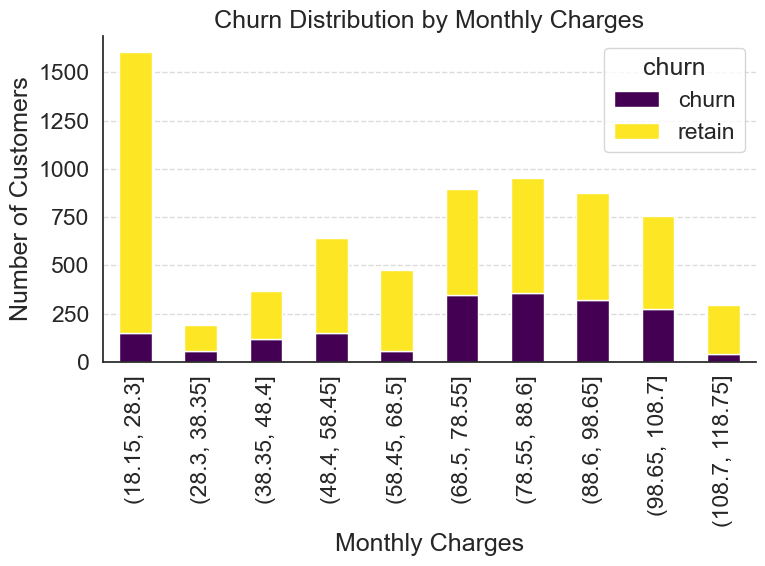

In [65]:
fig, ax = plt.subplots(figsize=(8, 6))

# Create a bar plot to show the distribution of churn by monthly charges
data_viz['monthly_charges_bins'] = pd.cut(data_viz['monthly_charges'], bins=10)
churn_by_charges = data_viz.groupby(['monthly_charges_bins', 'churn']).size().unstack().fillna(0)
churn_by_charges.plot(kind='bar', stacked=True, ax=ax, colormap='viridis')

# Customize the plot
ax.set_xlabel('Monthly Charges')
ax.set_ylabel('Number of Customers')
ax.set_title('Churn Distribution by Monthly Charges')

# Add grid lines for better readability
ax.grid(True, axis='y', linestyle='--', alpha=0.7)

# Remove unnecessary spines
sns.despine(left=False, bottom=False)

plt.tight_layout()
plt.show()

It has no clear trend
<br><br>
As we can see, at 60 it goes down, suddenly goes up again, and then drops again when the monthly charges are more than 100.
<br><br>
It can be said that a high price also gets a worthy benefit so that customers feel "Ah, it's worth spending my precious money for this".
<br><br>
Even so, we can suggest the business team minimize this churn rate for some specific segments. For example, by adding certain privileges to customers who have high monthly charges.

### 4.5.4. Numerical Data Distribution

C:\Users\muzny\AppData\Local\Temp\ipykernel_17492\2966756550.py:7: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.


C:\Users\muzny\AppData\Local\Temp\ipykernel_17492\2966756550.py:7: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.


C:\Users\muzny\AppData\Local\Temp\ipykernel_17492\2966756550.py:7: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.




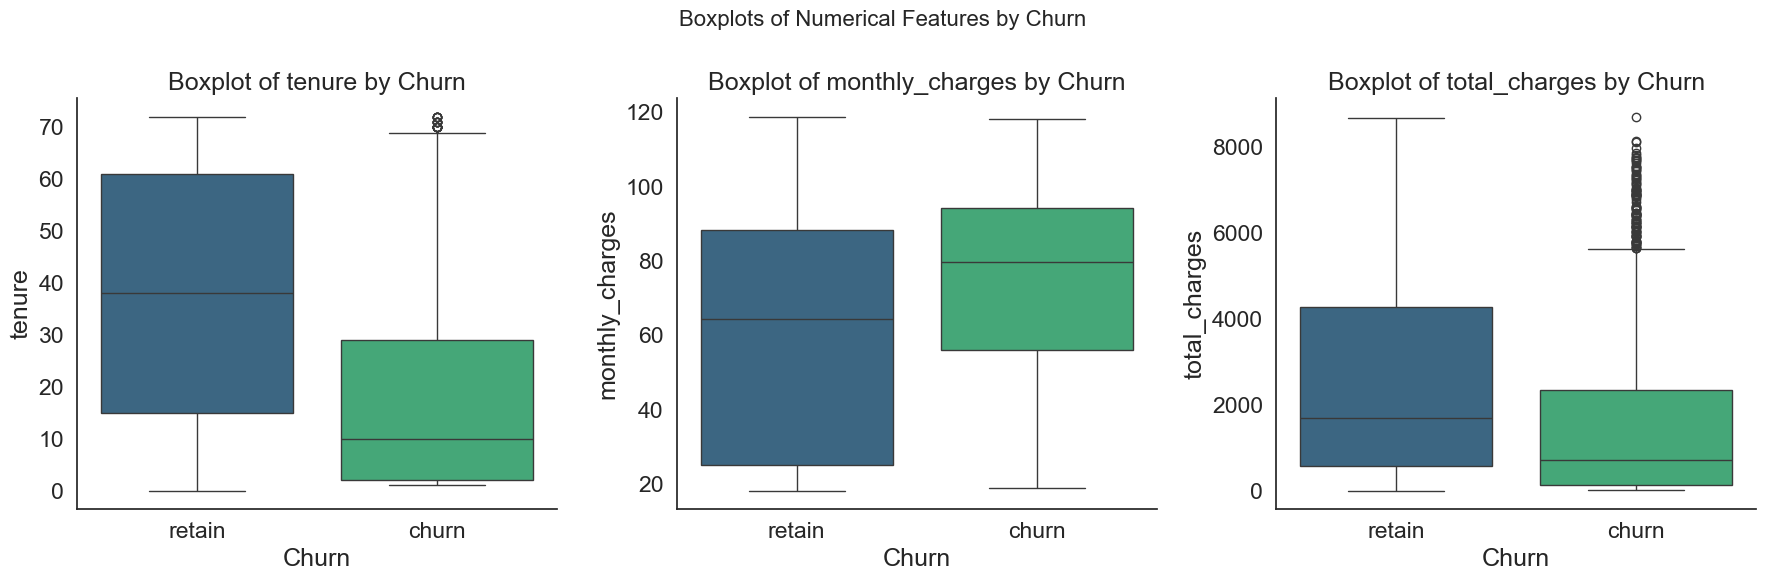

In [132]:
fig, ax = plt.subplots(1, 3, figsize=(18,6))

# Add a title for the entire plot
fig.suptitle('Boxplots of Numerical Features by Churn', fontsize=16)

for i, col in enumerate(column_numerical):
    sns.boxplot(data=data_viz, x='churn', y=col, ax=ax[i], palette='viridis')
    ax[i].set_title(f'Boxplot of {col} by Churn')
    ax[i].set_xlabel('Churn')
    ax[i].set_ylabel(col)

plt.tight_layout()
sns.despine()
plt.show()

As we can see, the numerical data distribution is not in normal distribution.

## 4.6. Attribute Associations to Churn Status

"Does this attribute have a strong relationship with churn status?"
<br><br>
To answer this question, I will calculate the association between attributes and target variable. Technically, association refers to any relationship between two variables, whereas correlation is often used to refer only to a linear relationship between two variables. ([Analyse-it](https://analyse-it.com/docs/user-guide/multivariate/correlation))
<br><br>
Cramer’s V is a measure of association between two nominal variables, giving a value between 0 and +1 (inclusive). It is based on Pearson's chi-squared statistic. ([Wikipedia](https://en.wikipedia.org/wiki/Cram%C3%A9r%27s_V))
<br><br>
Shaked Zychlinski had made a clear explanation about the correlation between categorical features. You can read it on his [Medium](https://towardsdatascience.com/the-search-for-categorical-correlation-a1cf7f1888c9). He also writes his own library, you can find it on his [GitHub](https://github.com/shakedzy/dython). The documentation can be found [here](http://shakedzy.xyz/dython/).
<br><br>
In human language, this associations function is used to calculate the correlation between attributes using some scenarios:
- Numerical & numerical attributes (`num_num_assoc`), used to calculate numerical-numerical association using:
  - Pearson's R (`pearson`)
  - Spearman's R (`spearman`)
  - Kendall's Tau (`kendall`)
- Nominal & nominal attributes (`nom_nom_assoc`), used to calculate nominal-nominal association using:
  - Cramer's V (`cramer`)
  - Theil 's U (`theil`)
- Nominal & numerical attributes (`nom_num_assoc`), used to calculate nominal-numerical association using:
  - Correlation ratio (`correlation_ratio`)
<br><br>

I won't deep down the detailed explanation, you can read it on his Medium or package documentation.

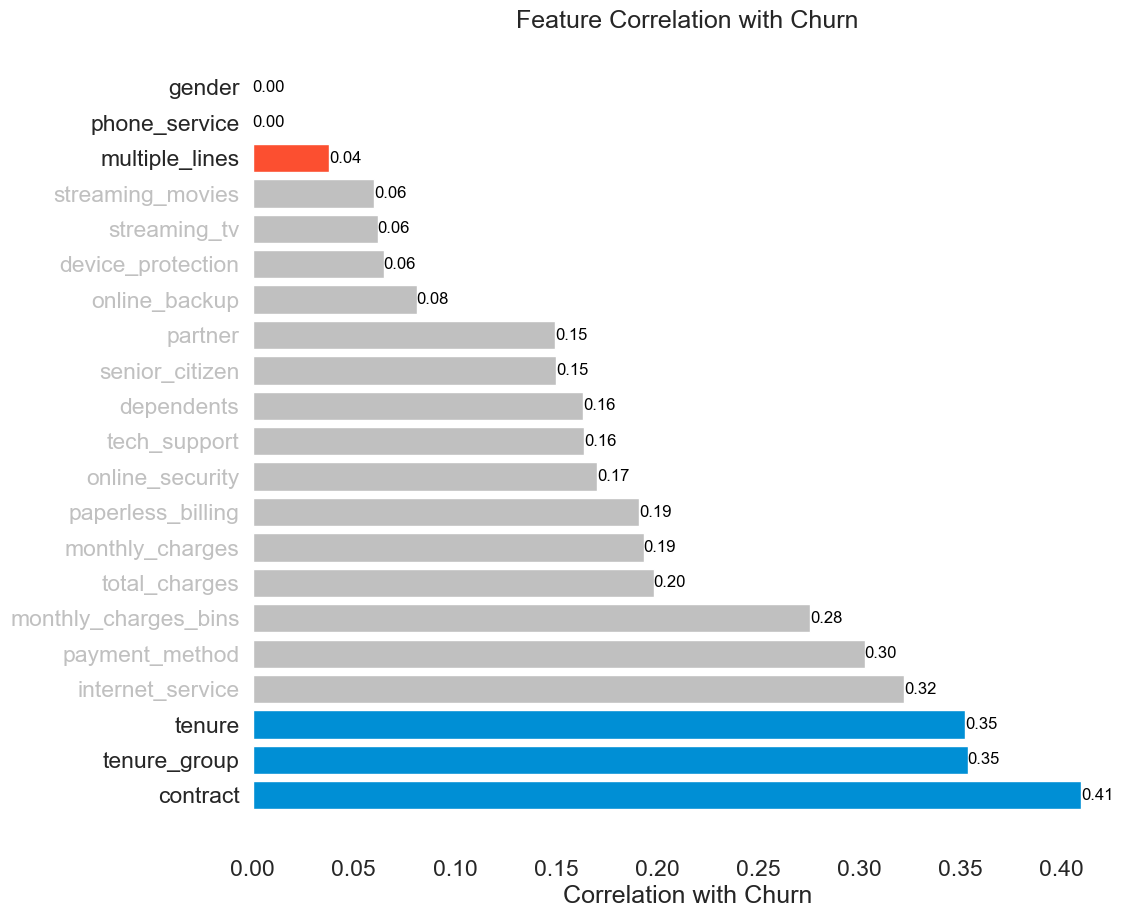

In [69]:
# calculate the associations (correlation) between features
associations_out = associations(data_viz,
                                nominal_columns=column_categorical,
                                numerical_columns=column_numerical,
                                nom_nom_assoc='cramer',
                                compute_only=True)

# the output is a dict {'ax', 'corr'}
corr_all = associations_out['corr']

corr_target = corr_all['churn'].drop('churn').sort_values(ascending=False)

# custom palette top 3
threshold_top = 3
threshold_bot = corr_target.size - 3 - 1
palette = []
for i in range(0, len(corr_target)):
  if i < threshold_top:
    palette.append('#008FD5') # blue
  elif i > threshold_bot:
    palette.append('#FC4F30') # red
  else:
    palette.append('silver')

fig, ax = plt.subplots(figsize=(10, 10))

# Create a horizontal bar plot
ax.barh(corr_target.index, corr_target.values, color=palette)

# Add labels to the bars
for i, (value, name) in enumerate(zip(corr_target.values, corr_target.index)):
    ax.text(value, i, f'{value:.2f}', va='center', ha='right' if value < 0 else 'left', 
            color='black', fontsize=12, fontweight='medium')

# Set labels and title
ax.set_xlabel('Correlation with Churn')
ax.set_title('Feature Correlation with Churn')

# Customize y-axis label colors
for i, label in enumerate(ax.get_yticklabels()):
    if (i >= threshold_top) and (i <= threshold_bot):
        label.set_color('silver')

sns.despine(left=True, bottom=True)
plt.show()

Well, here we can see the association of each attribute with churn status, whether it's retain or churn.
<br><br>
As we can see, the type of contract, tenure, and internet service are the 3 attributes that have the strongest relationship to churn status.
<br><br>
Meanwhile, gender, phone service, and multiple lines are the 3 attributes that have the weakest relationship to churn status.
<br><br>
Always remember, "correlation does not imply causation". I'm just trying to figure out the relationship between the attributes and the target variable, not the causality between them.

# 5. Data Preprocessing

## 5.1. Train - Test Split

I use a 70% : 30% ratio for the training set and testing set respectively.

In [133]:
data_X = data.drop('churn', axis=1)
data_y = data['churn']

X_train, X_test, y_train, y_test = train_test_split(data_X, data_y, test_size=0.3,
                                                    random_state=1, stratify=data_y)

In [134]:
print('X shape\t\t:', data_X.shape)
print('y shape\t\t:', data_y.shape)
print()
print('X_train shape\t:', X_train.shape)
print('y_train shape\t:', y_train.shape)
print()
print('X_test shape\t:', X_test.shape)
print('y_test shape\t:', y_test.shape)

X shape		: (7043, 19)
y shape		: (7043,)

X_train shape	: (4930, 19)
y_train shape	: (4930,)

X_test shape	: (2113, 19)
y_test shape	: (2113,)


## 5.2. Label Encoding

I use it for the target variable (label).

In [135]:
le = LabelEncoder()

le.fit(y_train)

y_train_encode = le.transform(y_train)
y_test_encode = le.transform(y_test)

In [136]:
le.classes_

array(['No', 'Yes'], dtype=object)

From this output, we can say that retaining customers (`churn = No`) will be encoded as `0`, and churned customers (`churn = Yes`) will be encoded as `1`.

In [137]:
print(y_train[:5].values)
print(y_train_encode[:5])

['No' 'Yes' 'No' 'Yes' 'No']
[0 1 0 1 0]


## 5.3. One Hot Encoding

I use one-hot encoding for input variables (attributes or features) because each feature has no natural ordering.
<br><br>
I'm dropping 1 category if the feature only has 2 categories. I do this to avoid multicollinearities and redundant columns.
<br><br>
Multicollinearity is a condition where some independent variables are highly correlated to each other. A perfect correlation is a condition when two independent variables have a +1.0 or -1.0 correlation. The perfect correlation between independent variables can lead to a singularity.
<br><br>
The simplest way to solve this problem is dropping 1 column when doing one-hot encoding. We can also drop 1 column only if the feature has a binary category.
<br><br>
The scikit-learn [documentation](https://scikit-learn.org/stable/modules/preprocessing) said: Such functionality is useful, for example, when using non-regularized regression (LinearRegression), since co-linearity would cause the covariance matrix to be non-invertible.
<br><br>
Jessica Miles had written some good explanations about multicollinearity and the effect of dropping a column (first column or average column) from the encoded data. You can read [here](https://towardsdatascience.com/drop-first-can-hurt-your-ols-regression-models-interpretability-4ca529cfb707).

In [138]:
# drop 1 category if the feature only has 2 categories
ohe = OneHotEncoder(sparse=False, drop='if_binary')

ohe.fit(X_train[column_categorical])

X_train_ohe = ohe.transform(X_train[column_categorical])
X_test_ohe = ohe.transform(X_test[column_categorical])

c:\Users\muzny\anaconda3\envs\spectrsocopy\lib\site-packages\sklearn\preprocessing\_encoders.py:972: FutureWarning:

`sparse` was renamed to `sparse_output` in version 1.2 and will be removed in 1.4. `sparse_output` is ignored unless you leave `sparse` to its default value.



In [139]:
X_train_ohe

array([[1., 0., 0., ..., 0., 0., 1.],
       [0., 1., 1., ..., 0., 0., 0.],
       [1., 0., 1., ..., 1., 0., 0.],
       ...,
       [0., 0., 1., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [1., 0., 0., ..., 0., 1., 0.]])

## 5.4. Encoded Dataframe

I will combine the encoded features and the numerical features. Make sure that the index is the same.

In [140]:
column_ohe = ohe.get_feature_names_out()
column_ohe

array(['gender_Male', 'senior_citizen_Yes', 'partner_Yes',
       'dependents_Yes', 'phone_service_Yes', 'multiple_lines_Yes',
       'internet_service_DSL', 'internet_service_Fiber optic',
       'internet_service_No', 'online_security_Yes', 'online_backup_Yes',
       'device_protection_Yes', 'tech_support_Yes', 'streaming_tv_Yes',
       'streaming_movies_Yes', 'contract_Month-to-month',
       'contract_One year', 'contract_Two year', 'paperless_billing_Yes',
       'payment_method_Bank transfer (automatic)',
       'payment_method_Credit card (automatic)',
       'payment_method_Electronic check', 'payment_method_Mailed check'],
      dtype=object)

I will rename the column name to `snake_case` format.

In [141]:
for i, col in enumerate(column_ohe):
  column_ohe[i] = inflection.underscore(column_ohe[i]).replace(' ', '_').replace('_(automatic)','')

column_ohe

array(['gender_male', 'senior_citizen_yes', 'partner_yes',
       'dependents_yes', 'phone_service_yes', 'multiple_lines_yes',
       'internet_service_dsl', 'internet_service_fiber_optic',
       'internet_service_no', 'online_security_yes', 'online_backup_yes',
       'device_protection_yes', 'tech_support_yes', 'streaming_tv_yes',
       'streaming_movies_yes', 'contract_month_to_month',
       'contract_one_year', 'contract_two_year', 'paperless_billing_yes',
       'payment_method_bank_transfer', 'payment_method_credit_card',
       'payment_method_electronic_check', 'payment_method_mailed_check'],
      dtype=object)

### 5.4.1. Train Set

In [142]:
X_train.head()

,gender,senior_citizen,partner,dependents,tenure,phone_service,multiple_lines,internet_service,online_security,online_backup,device_protection,tech_support,streaming_tv,streaming_movies,contract,paperless_billing,payment_method,monthly_charges,total_charges
6427,Male,No,No,No,41,Yes,No,No,No,No,No,No,No,No,Two year,No,Mailed check,20.15,802.35
6971,Female,Yes,Yes,No,18,Yes,Yes,Fiber optic,No,No,No,Yes,Yes,Yes,Month-to-month,No,Bank transfer (automatic),99.75,1836.25
96,Male,No,Yes,Yes,71,Yes,Yes,DSL,Yes,Yes,No,Yes,No,No,One year,Yes,Credit card (automatic),66.85,4748.70
5640,Male,No,No,No,1,Yes,No,Fiber optic,No,No,No,No,No,Yes,Month-to-month,No,Electronic check,79.60,79.60
414,Female,Yes,Yes,No,48,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Bank transfer (automatic),70.65,3545.05


In [143]:
# create dataframe from one-hot encoded features
X_train_ohe_df = pd.DataFrame(X_train_ohe, columns=column_ohe, index=X_train.index)

# combine the numerical and encoded features
X_train_encode = pd.concat([X_train.drop(columns=column_categorical), X_train_ohe_df], axis=1)
X_train_encode.head()

,tenure,monthly_charges,total_charges,gender_male,senior_citizen_yes,partner_yes,dependents_yes,phone_service_yes,multiple_lines_yes,internet_service_dsl,...,streaming_tv_yes,streaming_movies_yes,contract_month_to_month,contract_one_year,contract_two_year,paperless_billing_yes,payment_method_bank_transfer,payment_method_credit_card,payment_method_electronic_check,payment_method_mailed_check
6427,41,20.15,802.35,1.0,0.0,0.0,0.0,1.0,0.0,0.0,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0
6971,18,99.75,1836.25,0.0,1.0,1.0,0.0,1.0,1.0,0.0,...,1.0,1.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
96,71,66.85,4748.70,1.0,0.0,1.0,1.0,1.0,1.0,1.0,...,0.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,0.0
5640,1,79.60,79.60,1.0,0.0,0.0,0.0,1.0,0.0,0.0,...,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
414,48,70.65,3545.05,0.0,1.0,1.0,0.0,1.0,0.0,0.0,...,0.0,0.0,1.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0


### 5.4.2. Test Set

In [144]:
X_test.head()

,gender,senior_citizen,partner,dependents,tenure,phone_service,multiple_lines,internet_service,online_security,online_backup,device_protection,tech_support,streaming_tv,streaming_movies,contract,paperless_billing,payment_method,monthly_charges,total_charges
1630,Male,Yes,Yes,No,38,Yes,Yes,Fiber optic,No,Yes,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,102.60,4009.20
2008,Female,No,No,Yes,4,Yes,Yes,Fiber optic,No,No,Yes,Yes,No,No,Month-to-month,Yes,Mailed check,87.10,341.45
2685,Female,No,Yes,No,72,Yes,Yes,Fiber optic,Yes,Yes,Yes,No,Yes,No,Two year,No,Bank transfer (automatic),100.65,7334.05
903,Female,No,Yes,No,56,Yes,No,Fiber optic,Yes,Yes,Yes,No,Yes,Yes,One year,Yes,Credit card (automatic),105.60,6068.65
3905,Female,No,No,No,3,No,No,DSL,No,No,No,No,Yes,No,Month-to-month,No,Credit card (automatic),35.20,108.95


In [145]:
# create dataframe from one-hot encoded features
X_test_ohe_df = pd.DataFrame(X_test_ohe, columns=column_ohe, index=X_test.index)

# combine the numerical and encoded features
X_test_encode = pd.concat([X_test.drop(columns=column_categorical), X_test_ohe_df], axis=1)
X_test_encode.head()

,tenure,monthly_charges,total_charges,gender_male,senior_citizen_yes,partner_yes,dependents_yes,phone_service_yes,multiple_lines_yes,internet_service_dsl,...,streaming_tv_yes,streaming_movies_yes,contract_month_to_month,contract_one_year,contract_two_year,paperless_billing_yes,payment_method_bank_transfer,payment_method_credit_card,payment_method_electronic_check,payment_method_mailed_check
1630,38,102.60,4009.20,1.0,1.0,1.0,0.0,1.0,1.0,0.0,...,1.0,1.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0
2008,4,87.10,341.45,0.0,0.0,0.0,1.0,1.0,1.0,0.0,...,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0
2685,72,100.65,7334.05,0.0,0.0,1.0,0.0,1.0,1.0,0.0,...,1.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0
903,56,105.60,6068.65,0.0,0.0,1.0,0.0,1.0,0.0,0.0,...,1.0,1.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,0.0
3905,3,35.20,108.95,0.0,0.0,0.0,0.0,0.0,0.0,1.0,...,1.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0


### 5.4.3. Encoded Dataframe

In [146]:
# combine the X-train and X-test
data_encode = pd.concat([X_train_encode, X_test_encode], axis=0)

# combine with the y-train
data_encode = data_encode.join(pd.Series(y_train_encode, name='churn', index=X_train_encode.index), lsuffix='_1', rsuffix='_2')

# combine with the y-test
data_encode = data_encode.join(pd.Series(y_test_encode, name='churn', index=X_test_encode.index), lsuffix='_1', rsuffix='_2')

# merging the y-train and y-test column
data_encode['churn_1'].fillna(data_encode['churn_2'], inplace=True)
data_encode.drop(columns='churn_2', inplace=True)
data_encode.rename(columns={'churn_1':'churn'}, inplace=True)

data_encode.head()

,tenure,monthly_charges,total_charges,gender_male,senior_citizen_yes,partner_yes,dependents_yes,phone_service_yes,multiple_lines_yes,internet_service_dsl,...,streaming_movies_yes,contract_month_to_month,contract_one_year,contract_two_year,paperless_billing_yes,payment_method_bank_transfer,payment_method_credit_card,payment_method_electronic_check,payment_method_mailed_check,churn
6427,41,20.15,802.35,1.0,0.0,0.0,0.0,1.0,0.0,0.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0
6971,18,99.75,1836.25,0.0,1.0,1.0,0.0,1.0,1.0,0.0,...,1.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0
96,71,66.85,4748.70,1.0,0.0,1.0,1.0,1.0,1.0,1.0,...,0.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0
5640,1,79.60,79.60,1.0,0.0,0.0,0.0,1.0,0.0,0.0,...,1.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0
414,48,70.65,3545.05,0.0,1.0,1.0,0.0,1.0,0.0,0.0,...,0.0,1.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0


## 5.5. Feature Scaling

Since this dataset is not in normal distribution, I will use min-max scaling for the numerical features.

In [147]:
X_train_scale = X_train_encode.copy()
X_test_scale = X_test_encode.copy()

for i in column_numerical:
  scaler = MinMaxScaler()
  scaler.fit(X_train_scale[[i]])

  X_train_scale[[i]] = scaler.transform(X_train_scale[[i]])
  X_test_scale[[i]] = scaler.transform(X_test_scale[[i]])

## 5.6. Scaled Dataframe
This dataframe has been encoded and scaled

In [148]:
# combine the X-train and X-test
data_scale = pd.concat([X_train_scale, X_test_scale], axis=0)

# combine with the y-train
data_scale = data_scale.join(pd.Series(y_train_encode, name='churn', index=X_train_scale.index), lsuffix='_1', rsuffix='_2')

# combine with the y-test
data_scale = data_scale.join(pd.Series(y_test_encode, name='churn', index=X_test_scale.index), lsuffix='_1', rsuffix='_2')

# merging the y-train and y-test column
data_scale['churn_1'].fillna(data_scale['churn_2'], inplace=True)
data_scale.drop(columns='churn_2', inplace=True)
data_scale.rename(columns={'churn_1':'churn'}, inplace=True)

data_scale.head()

,tenure,monthly_charges,total_charges,gender_male,senior_citizen_yes,partner_yes,dependents_yes,phone_service_yes,multiple_lines_yes,internet_service_dsl,...,streaming_movies_yes,contract_month_to_month,contract_one_year,contract_two_year,paperless_billing_yes,payment_method_bank_transfer,payment_method_credit_card,payment_method_electronic_check,payment_method_mailed_check,churn
6427,0.569,0.017,0.092,1.0,0.0,0.0,0.0,1.0,0.0,0.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0
6971,0.250,0.811,0.211,0.0,1.0,1.0,0.0,1.0,1.0,0.0,...,1.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0
96,0.986,0.483,0.547,1.0,0.0,1.0,1.0,1.0,1.0,1.0,...,0.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0
5640,0.014,0.610,0.009,1.0,0.0,0.0,0.0,1.0,0.0,0.0,...,1.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0
414,0.667,0.521,0.408,0.0,1.0,1.0,0.0,1.0,0.0,0.0,...,0.0,1.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0


In [149]:
data_scale_train = pd.concat([X_train_scale, pd.Series(y_train_encode, name='churn', index=X_train_scale.index)], axis=1)
data_scale_train.head()

,tenure,monthly_charges,total_charges,gender_male,senior_citizen_yes,partner_yes,dependents_yes,phone_service_yes,multiple_lines_yes,internet_service_dsl,...,streaming_movies_yes,contract_month_to_month,contract_one_year,contract_two_year,paperless_billing_yes,payment_method_bank_transfer,payment_method_credit_card,payment_method_electronic_check,payment_method_mailed_check,churn
6427,0.569,0.017,0.092,1.0,0.0,0.0,0.0,1.0,0.0,0.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0
6971,0.250,0.811,0.211,0.0,1.0,1.0,0.0,1.0,1.0,0.0,...,1.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1
96,0.986,0.483,0.547,1.0,0.0,1.0,1.0,1.0,1.0,1.0,...,0.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,0.0,0
5640,0.014,0.610,0.009,1.0,0.0,0.0,0.0,1.0,0.0,0.0,...,1.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1
414,0.667,0.521,0.408,0.0,1.0,1.0,0.0,1.0,0.0,0.0,...,0.0,1.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0


## 5.7. Correlation

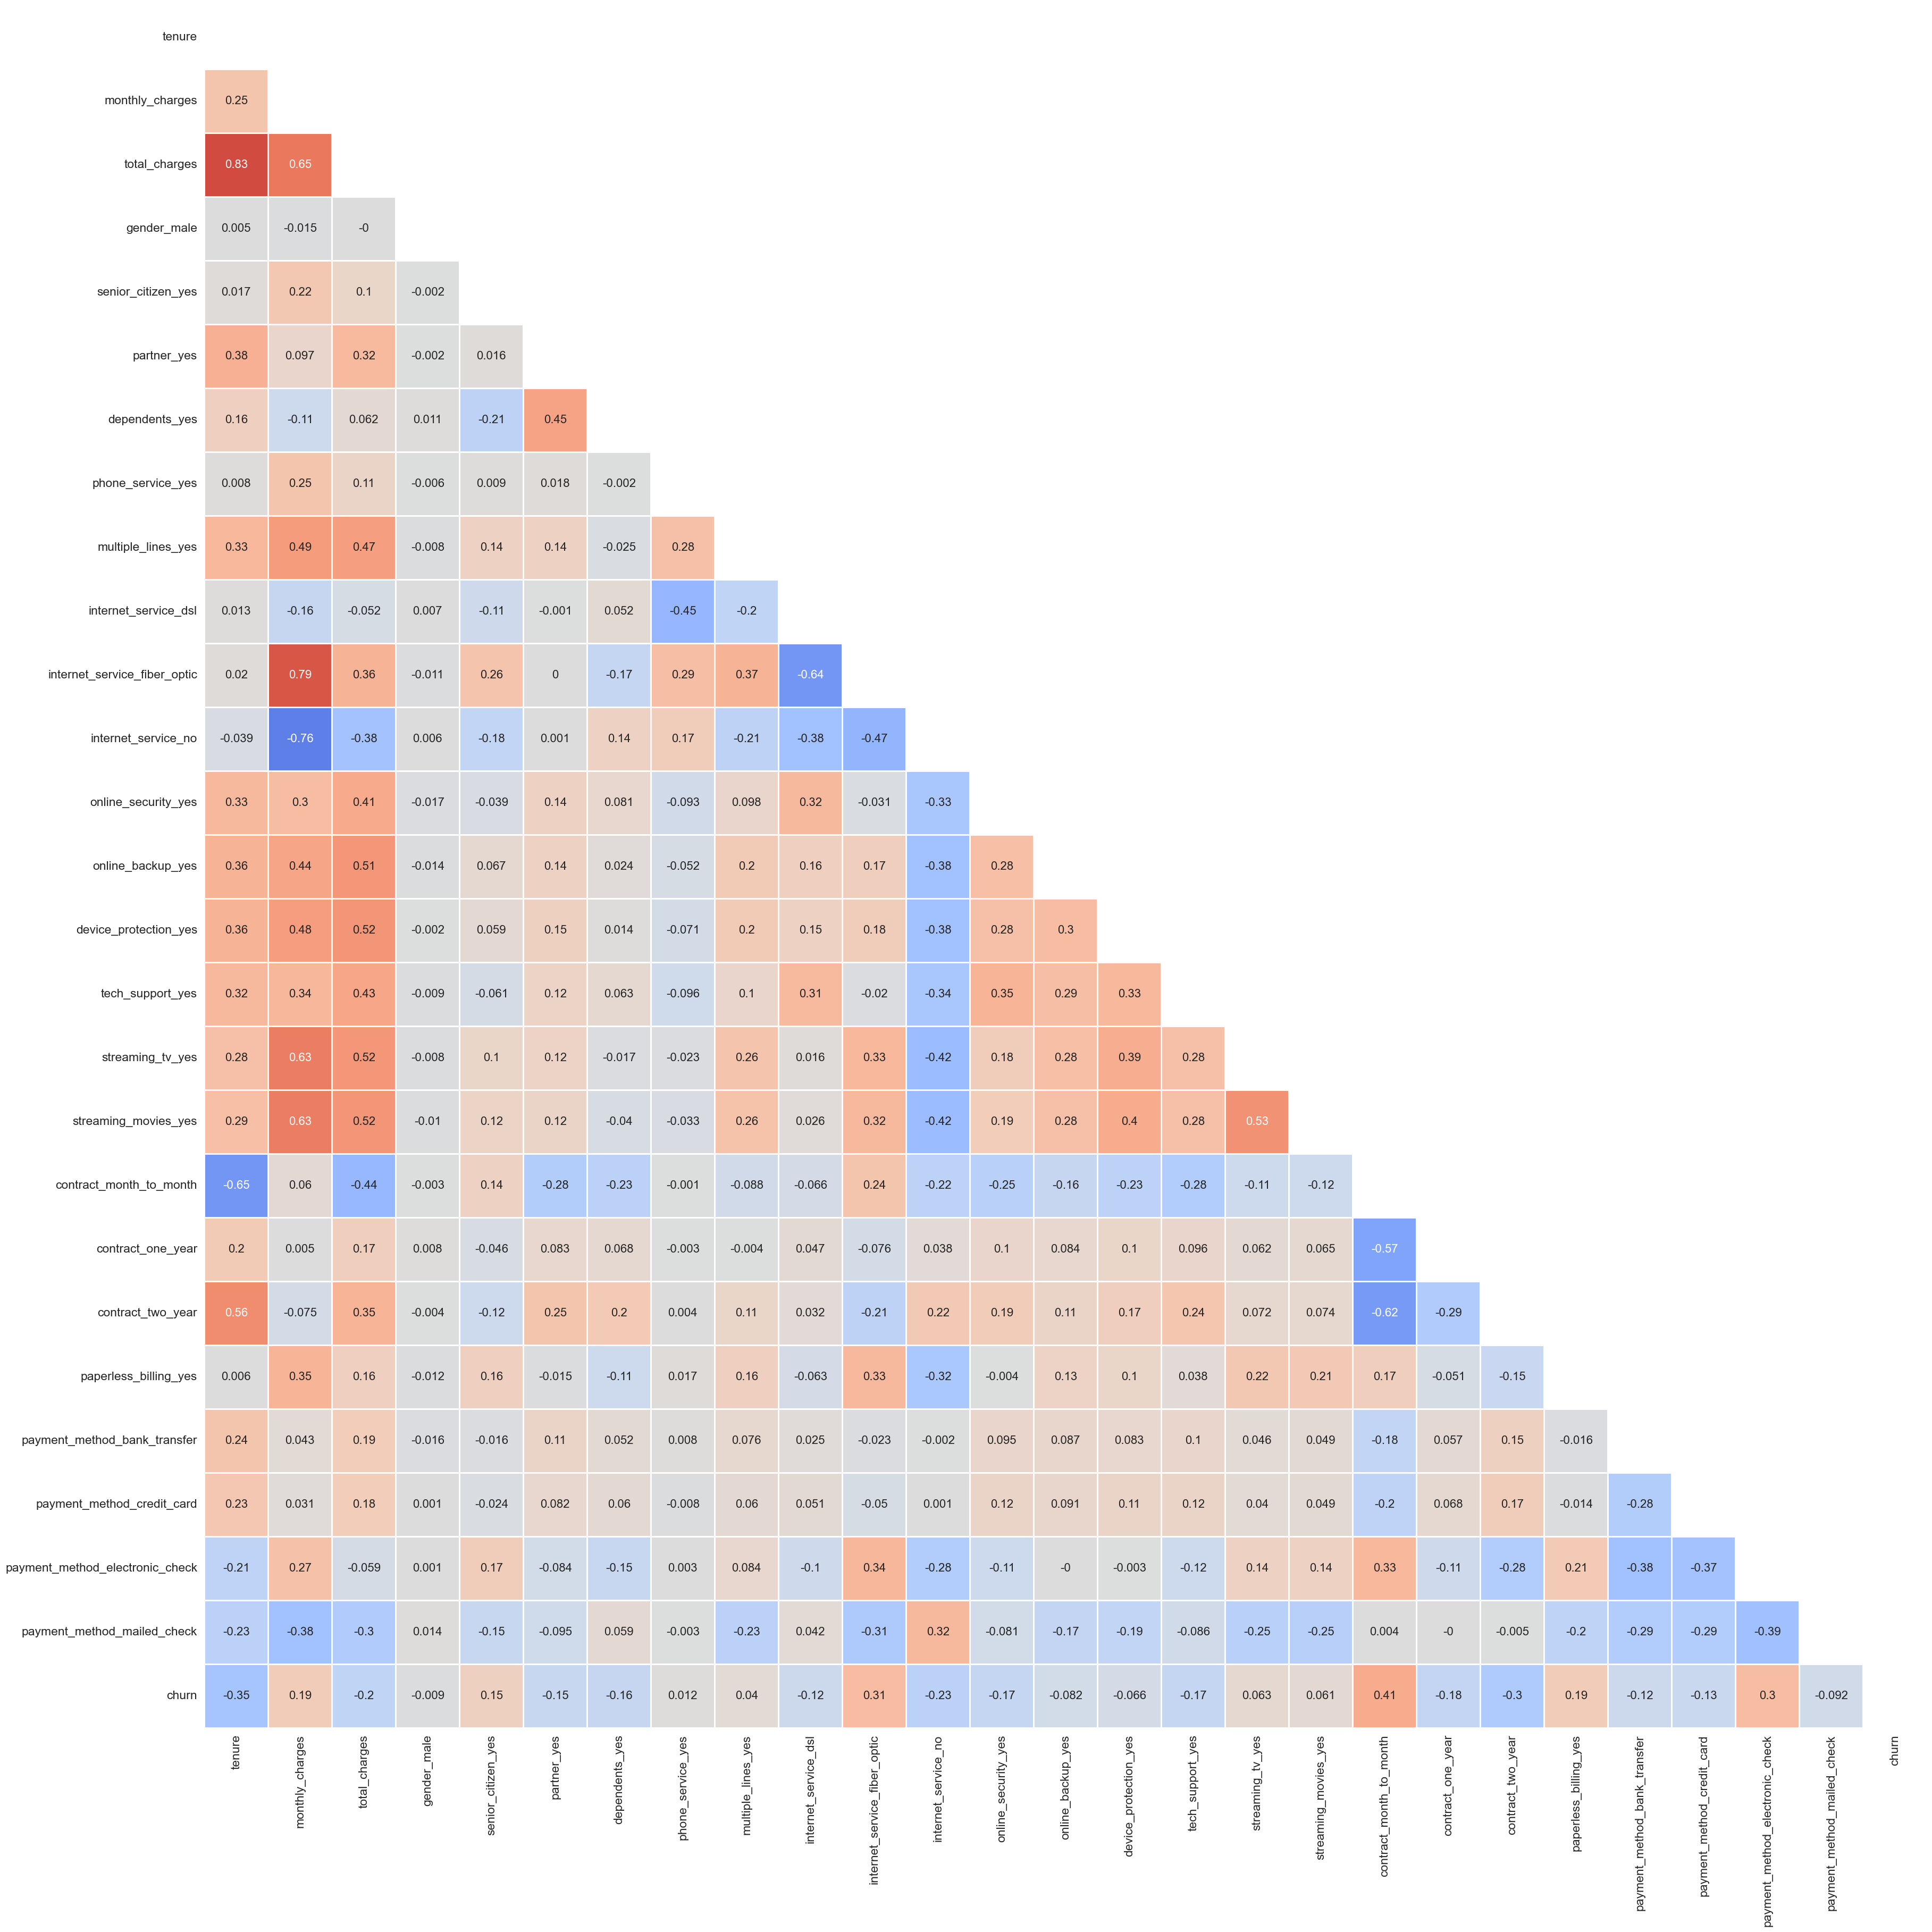

In [150]:
corr_matrix = data_scale.corr().round(3)

mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

fig, ax = plt.subplots(figsize=(40,40))
sns.heatmap(corr_matrix, vmin=-1, vmax=1, cbar=False,
            cmap='coolwarm', linewidth=1, mask=mask,
            square=True, annot=True, annot_kws={'fontsize':16}, ax=ax)

plt.show()

### 5.7.1. Positive Correlation

C:\Users\muzny\AppData\Local\Temp\ipykernel_17492\118831880.py:16: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.




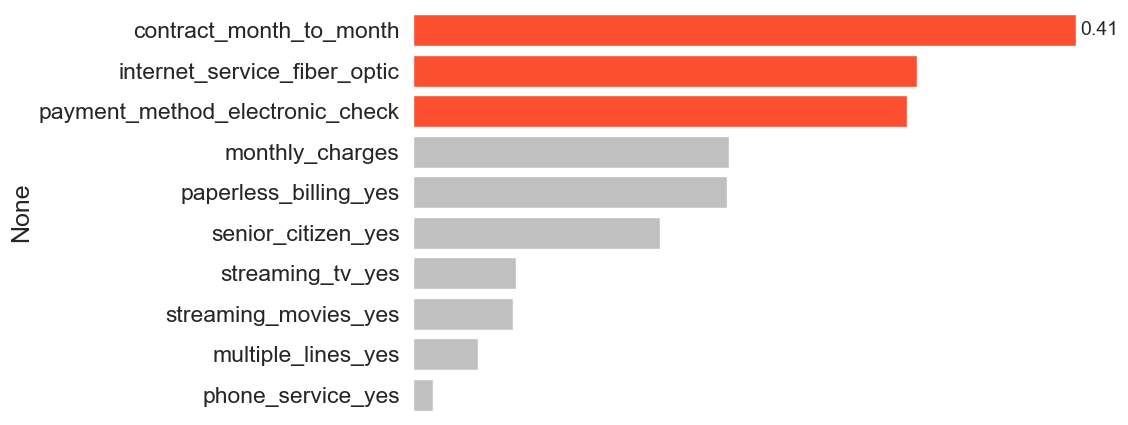

In [151]:
corr_matrix = data_scale.corr().round(3)
corr_target = corr_matrix['churn'].drop('churn').sort_values(ascending=False)

corr_positive = corr_target[corr_target >= 0]

threshold_top = 3
palette = []
for i in range(0, len(corr_positive)):
  if i < threshold_top:
    palette.append('#FC4F30') # red
  else:
    palette.append('silver')

fig, ax = plt.subplots(figsize=(8,5))

sns.barplot(x=corr_positive.values, y=corr_positive.index, ax=ax, palette=palette, saturation=1)

ax.bar_label(ax.containers[0], padding=3, fmt='%.2f', fontsize=14, fontweight='medium')

ax.set_xticklabels([])
sns.despine(left=True, bottom=True)
plt.show()

### 5.7.2. Negative Correlation

C:\Users\muzny\AppData\Local\Temp\ipykernel_17492\1955359572.py:14: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.




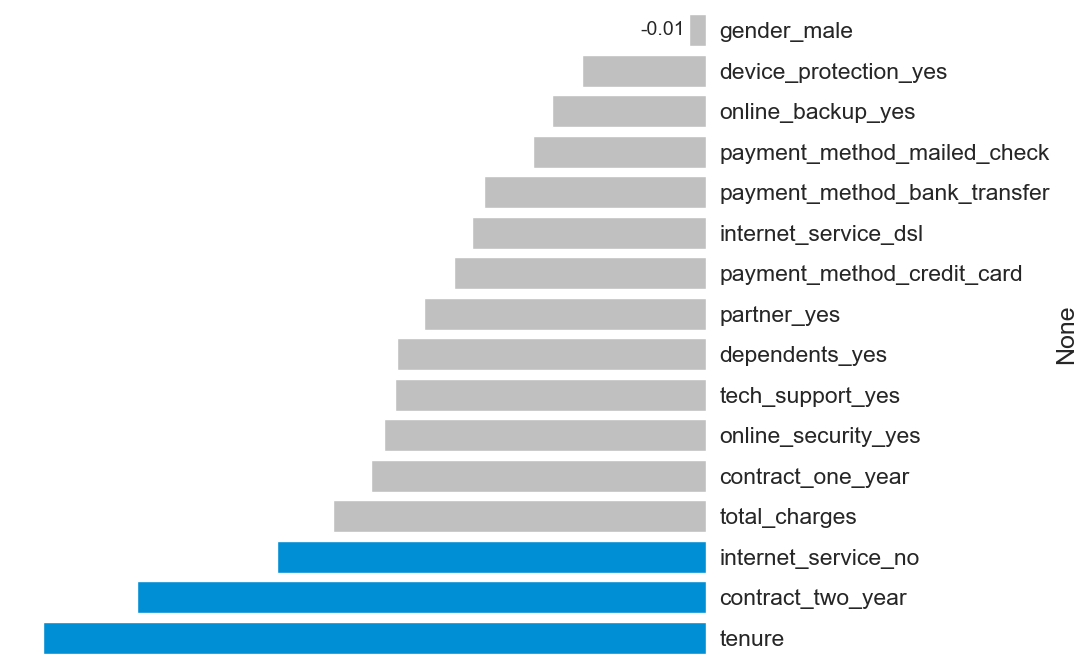

In [90]:
corr_negative = corr_target[corr_target < 0]

threshold_top = 3
threshold_bot = corr_negative.size - threshold_top - 1
palette = []
for i in range(0, len(corr_negative)):
  if i > threshold_bot:
    palette.append('#008FD5') # blue
  else:
    palette.append('silver')

fig, ax = plt.subplots(figsize=(8,8))

sns.barplot(x=corr_negative.values, y=corr_negative.index, ax=ax, palette=palette, saturation=1)

ax.bar_label(ax.containers[0], padding=3, fmt='%.2f', fontsize=14, fontweight='medium')

ax.yaxis.set_label_position("right")
ax.yaxis.tick_right()
ax.set_xticklabels([])

sns.despine(left=True, bottom=True)
plt.tick_params(right=False)
plt.show()

## 5.8. Oversampling with SMOTE

This dataset is imbalanced. So, my approach to get it balanced is to use SMOTE, one of the oversampling methods.

In [91]:
# numerical
column_numerical = ['tenure', 'monthly_charges', 'total_charges']

# categorical
column_categorical = list(data_scale.columns)
column_categorical.remove('tenure')
column_categorical.remove('monthly_charges')
column_categorical.remove('total_charges')

In [92]:
smote = SMOTE(random_state=1)

X_train_smote, y_train_smote = smote.fit_resample(X_train_scale, y_train_encode)

X_train_smote_df = pd.DataFrame(X_train_smote, columns=X_train_smote.columns)
y_train_smote_df = pd.DataFrame(y_train_smote, columns=['churn'])

data_smote = pd.concat([X_train_smote_df, y_train_smote_df], axis=1)

Let's take a look at the balanced dataframe.

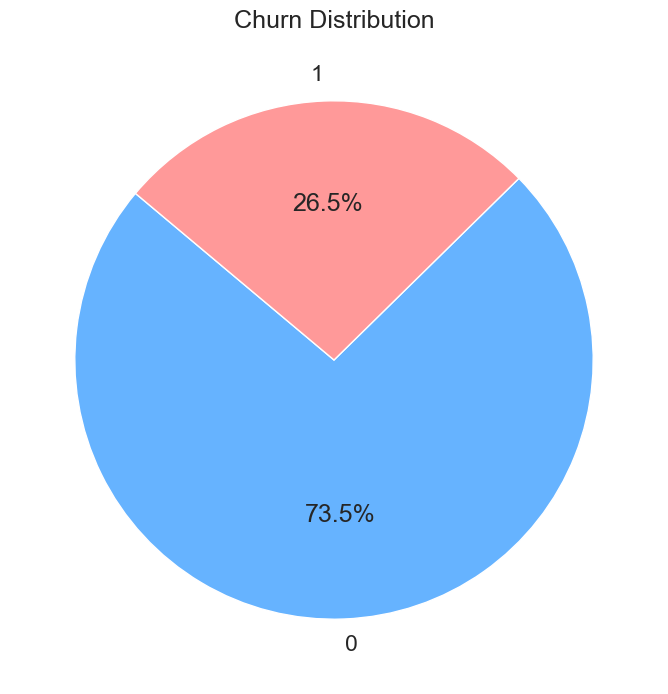

In [152]:
churn_counts = data_scale_train['churn'].value_counts()
plt.figure(figsize=(8, 8))
plt.pie(churn_counts, labels=churn_counts.index, autopct='%1.1f%%', startangle=140, colors=['#66b3ff','#ff9999'])
plt.title('Churn Distribution')
plt.show()

In [94]:
data_smote['churn'].value_counts()

churn
0    3622
1    3622
Name: count, dtype: int64

Now, both retain (0) and churn (1) categories have the same number.

In [153]:
data_smote

,tenure,monthly_charges,total_charges,gender_male,senior_citizen_yes,partner_yes,dependents_yes,phone_service_yes,multiple_lines_yes,internet_service_dsl,...,streaming_movies_yes,contract_month_to_month,contract_one_year,contract_two_year,paperless_billing_yes,payment_method_bank_transfer,payment_method_credit_card,payment_method_electronic_check,payment_method_mailed_check,churn
0,0.569,0.017,0.092,1.0,0.0,0.0,0.000,1.0,0.0,0.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0
1,0.250,0.811,0.211,0.0,1.0,1.0,0.000,1.0,1.0,0.0,...,1.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1
2,0.986,0.483,0.547,1.0,0.0,1.0,1.000,1.0,1.0,1.0,...,0.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,0.0,0
3,0.014,0.610,0.009,1.0,0.0,0.0,0.000,1.0,0.0,0.0,...,1.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1
4,0.667,0.521,0.408,0.0,1.0,1.0,0.000,1.0,0.0,0.0,...,0.0,1.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7239,0.373,0.612,0.250,1.0,0.0,0.0,0.969,1.0,1.0,0.0,...,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,1
7240,0.014,0.516,0.008,0.0,0.0,0.0,0.000,1.0,0.0,0.0,...,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,1
7241,0.014,0.513,0.008,1.0,0.0,0.0,0.000,1.0,0.0,0.0,...,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,1
7242,0.261,0.668,0.181,1.0,1.0,1.0,0.000,1.0,1.0,0.0,...,1.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1


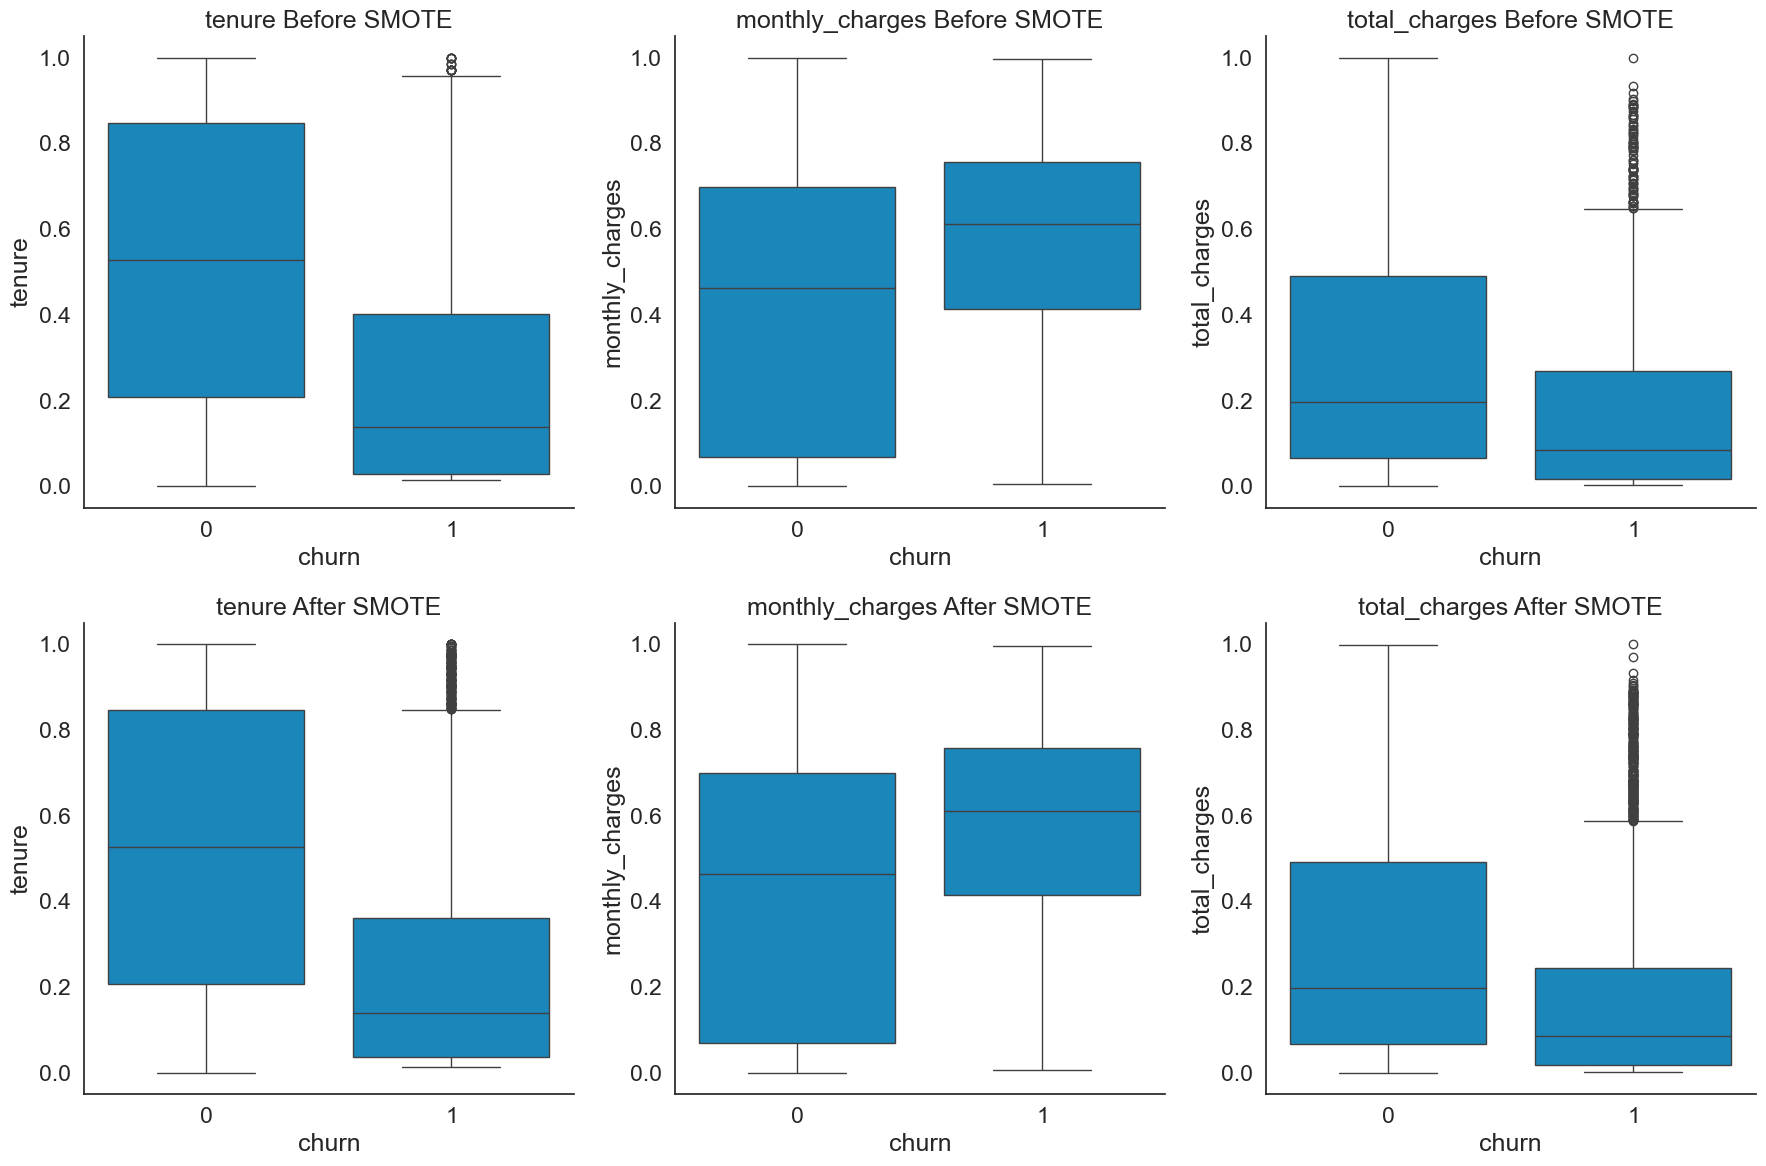

In [95]:
fig, ax = plt.subplots(2, 3, figsize=(18,12))
axes_list = [axes for axes_row in ax for axes in axes_row]

for i, col in enumerate(column_numerical):
    sns.boxplot(data=data_scale_train, x='churn', y=col, ax=axes_list[i])
    axes_list[i].set_title(f'{col} Before SMOTE')

for i, col in enumerate(column_numerical):
    sns.boxplot(data=data_smote, x='churn', y=col, ax=axes_list[i+3])
    axes_list[i+3].set_title(f'{col} After SMOTE')

plt.tight_layout()
sns.despine()

plt.show()

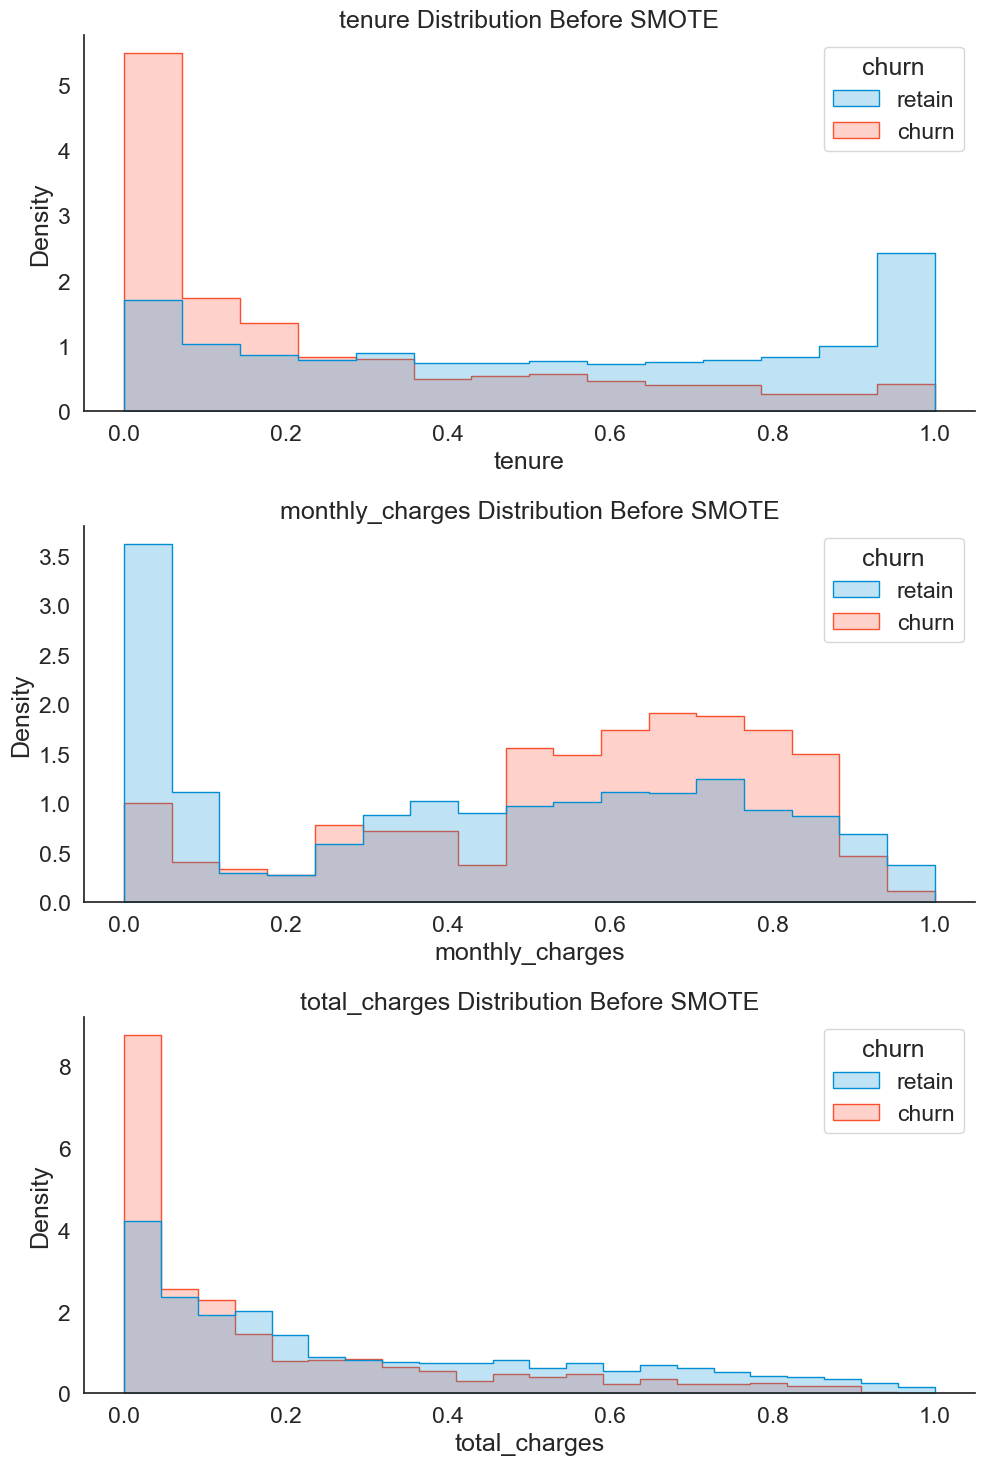

In [97]:
tmp_df = data_scale_train.copy()
tmp_df.loc[:,'churn'] = tmp_df.loc[:,'churn'].apply(lambda x: 'churn' if x == 1 else 'retain')

fig, axes = plt.subplots(len(column_numerical), 1, figsize=(10, 5 * len(column_numerical)))

for i, col in enumerate(column_numerical):
    sns.histplot(data=tmp_df, x=col, hue='churn', element='step', stat='density', common_norm=False, ax=axes[i])
    axes[i].set_title(f'{col} Distribution Before SMOTE')

plt.tight_layout()
sns.despine()

plt.show()

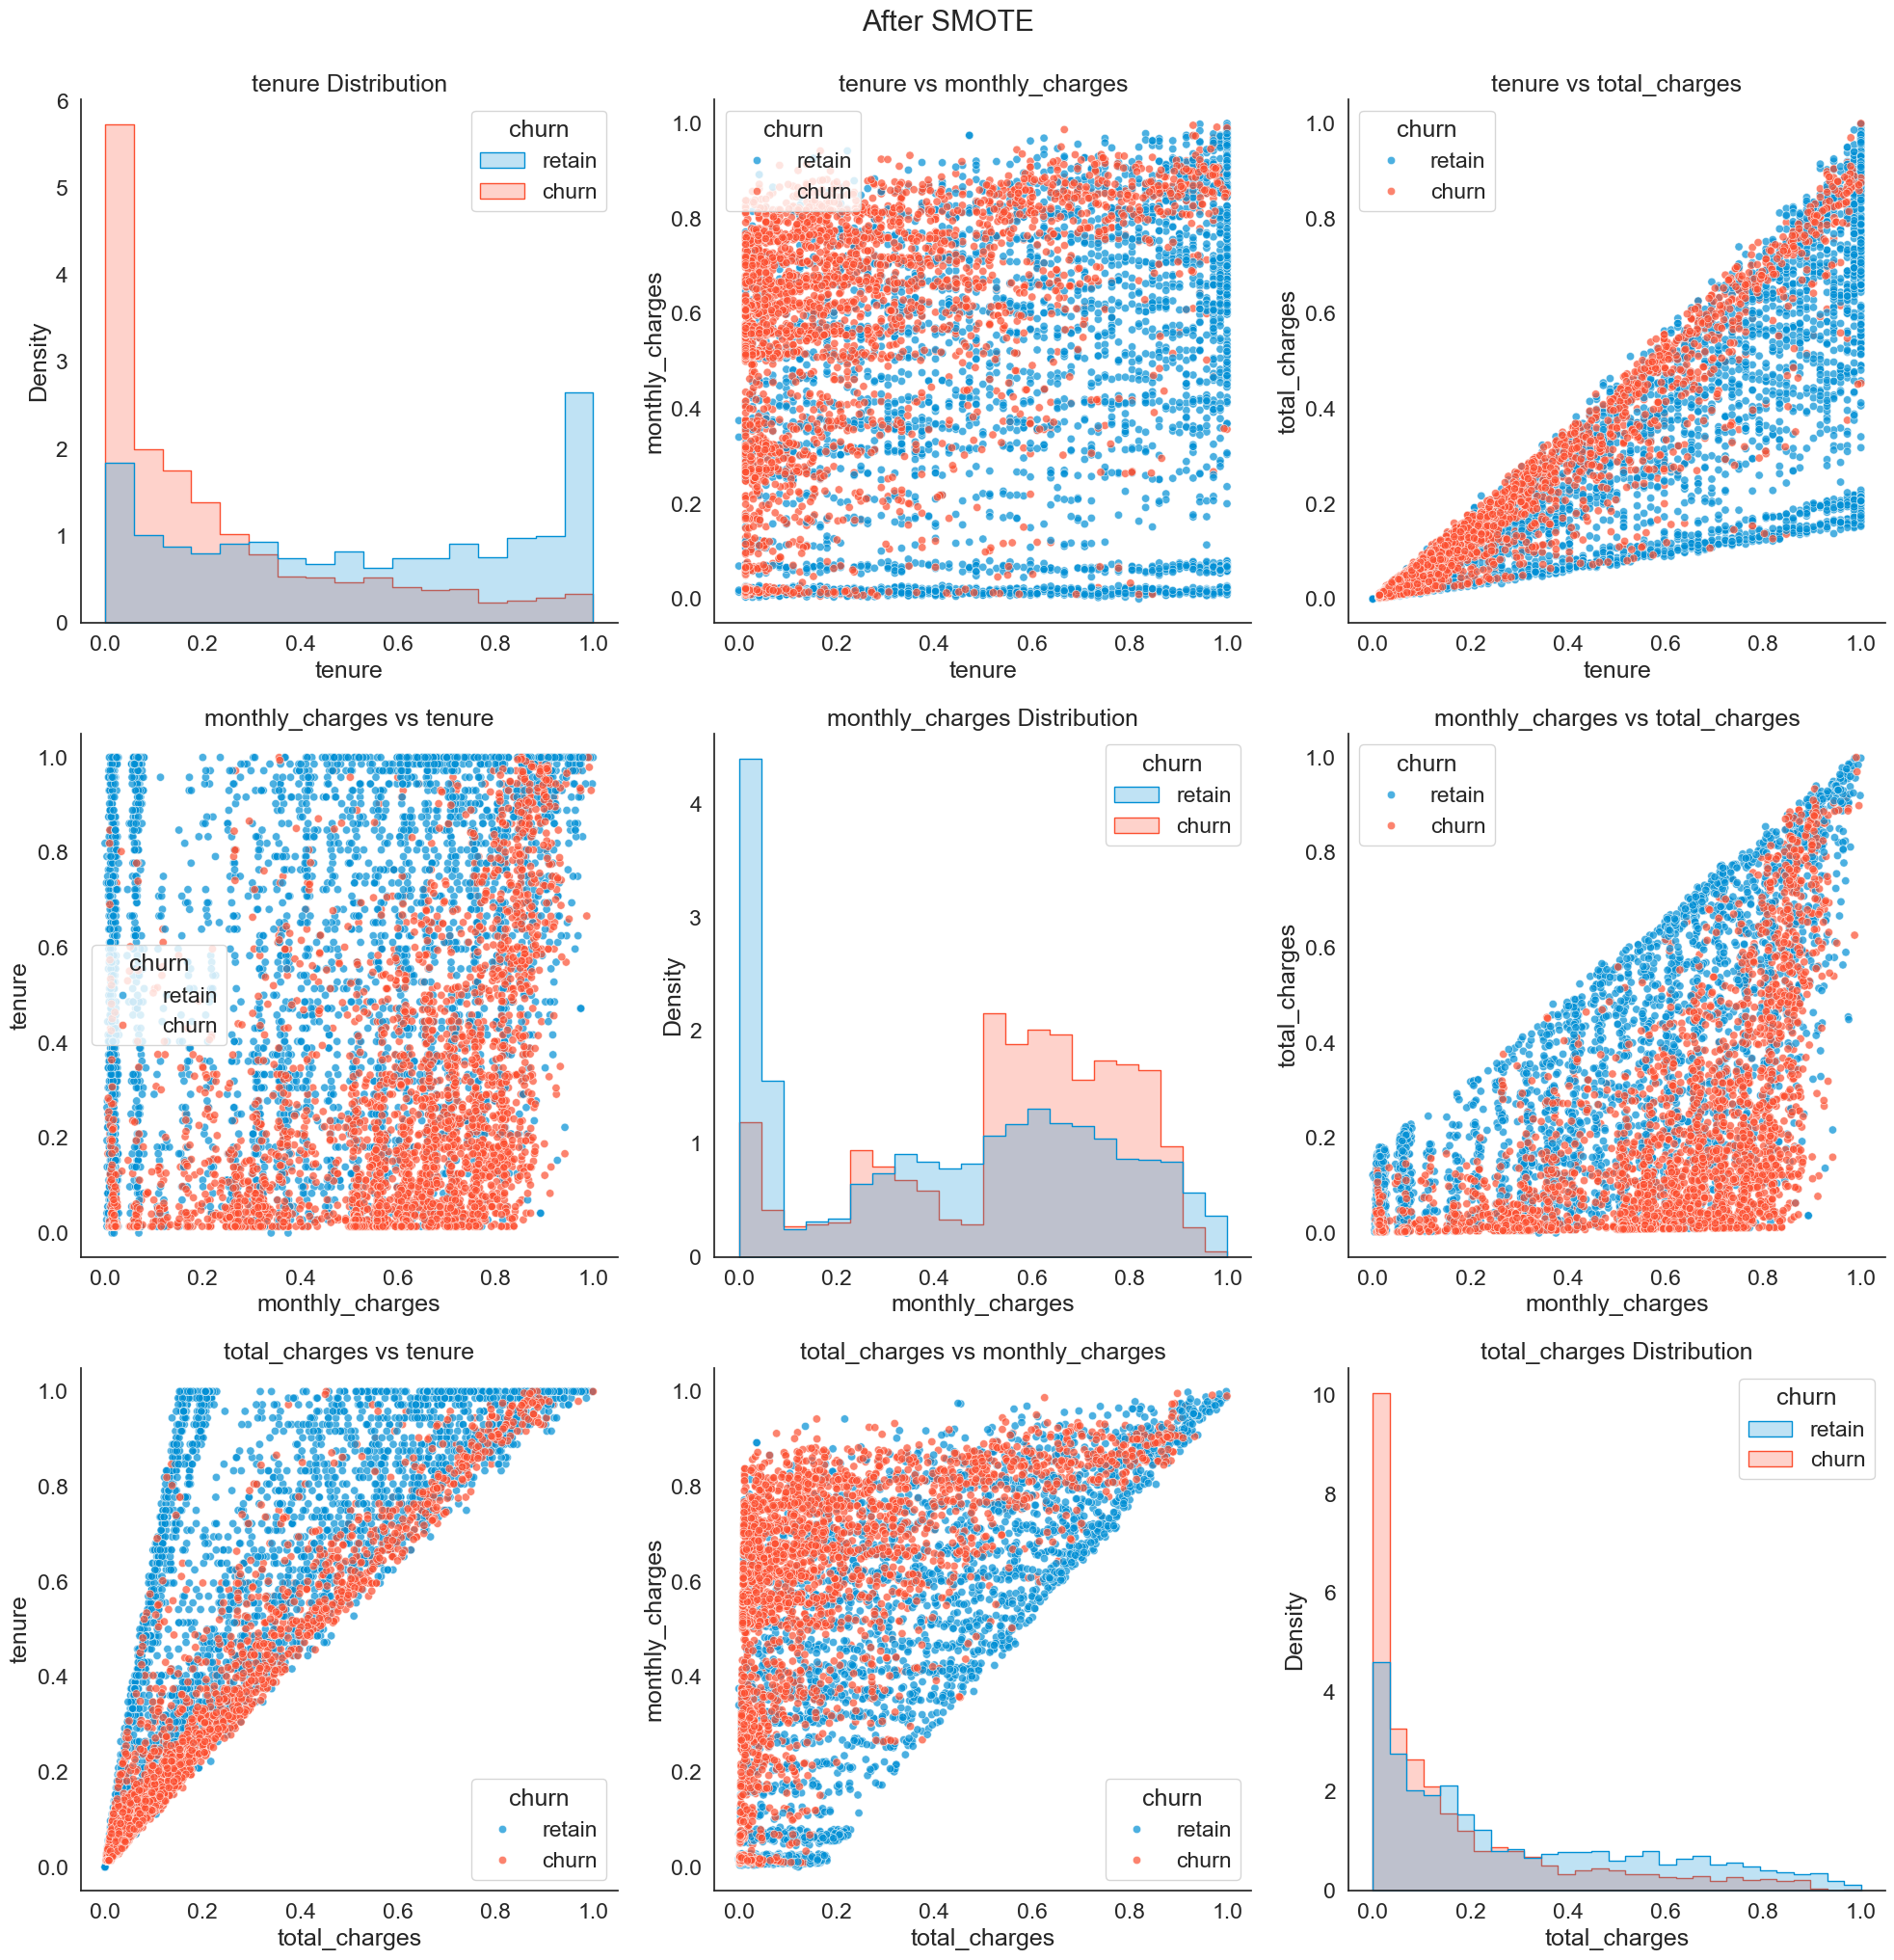

In [154]:
# Visualizing the Distribution and Pairwise Relationships of Numerical Features After SMOTE
tmp_df = data_smote.copy()
tmp_df.loc[:,'churn'] = tmp_df.loc[:,'churn'].apply(lambda x: 'churn' if x == 1 else 'retain')

fig, axes = plt.subplots(len(column_numerical), len(column_numerical), figsize=(20, 20))

for i, col1 in enumerate(column_numerical):
    for j, col2 in enumerate(column_numerical):
        if i == j:
            sns.histplot(data=tmp_df, x=col1, hue='churn', element='step', stat='density', common_norm=False, ax=axes[i, j])
            axes[i, j].set_title(f'{col1} Distribution')
        else:
            sns.scatterplot(data=tmp_df, x=col1, y=col2, hue='churn', alpha=0.7, ax=axes[i, j])
            axes[i, j].set_title(f'{col1} vs {col2}')

plt.tight_layout()
sns.despine()

plt.suptitle('After SMOTE', y=1.02)
plt.show()

# 6. Model Development & Evaluation

## 6.1. Scoring Function

### 6.1.1. Get Score

In [164]:
def get_score(y_pred_list, y_test, average=None, plot=True, axis=0, cmap='Reds'):
  model_name = []
  accuracy = []
  precision = []
  recall = []
  f1 = []
  roc_auc = []

  for name, y_pred in y_pred_list.items():
    model_name.append(name)
    if average != None:
      accuracy.append(accuracy_score(y_test, y_pred))
      precision.append(precision_score(y_test, y_pred, average=average))
      recall.append(recall_score(y_test, y_pred, average=average))
      f1.append(f1_score(y_test, y_pred, average=average))
      roc_auc.append(roc_auc_score(y_test, y_pred, average=average))

      score_list = {
        'model':model_name,
        'accuracy':accuracy,
        f'{average}_avg_precision':precision,
        f'{average}_avg_recall':recall,
        f'{average}_avg_f1_score':f1,
        'roc_auc':roc_auc
      }
    else:
      accuracy.append(accuracy_score(y_test, y_pred))
      precision.append(precision_score(y_test, y_pred))
      recall.append(recall_score(y_test, y_pred))
      f1.append(f1_score(y_test, y_pred))
      roc_auc.append(roc_auc_score(y_test, y_pred))

      score_list = {
        'model':model_name,
        'accuracy':accuracy,
        'precision':precision,
        'recall':recall,
        'f1_score':f1,
        'roc_auc':roc_auc
      }

  score_df = pd.DataFrame(score_list).set_index('model')

  if plot:
    display(score_df.style.background_gradient(axis=axis, cmap=cmap))

  return score_df

### 6.1.2. Harmonic Mean
Harmonic mean between accuracy and recall

In [165]:
def fbeta_score(accuracy, recall, beta=1):
  fbeta_score = (1 + beta**2) * (accuracy*recall)/(beta*accuracy+recall)
  
  return fbeta_score

## 6.2. Default Parameter

In [166]:
model_list = {
    'Logistic Regression':LogisticRegression(max_iter=1000, random_state=1),
    'Ridge Classifier':RidgeClassifier(random_state=1),
    'KNN':KNeighborsClassifier(),
    'SVC':SVC(random_state=1),
    'Neural Network':MLPClassifier(max_iter=1000, random_state=1),
    'Decision Tree':DecisionTreeClassifier(random_state=1),
    'Random Forest':RandomForestClassifier(random_state=1),
    'Gradient Boosting Classifier':GradientBoostingClassifier(random_state=1),
    'AdaBoost Classifier':AdaBoostClassifier(random_state=1),
    'CatBoost Classifier':CatBoostClassifier(random_state=1, verbose=False),
    'Hist Gradient Boosting':HistGradientBoostingClassifier(random_state=1),
    'XGBoost':XGBClassifier(random_state=1, use_label_encoder=False, eval_metric='logloss'),
    'LightGBM':LGBMClassifier(random_state=1),
}

X_train_model = X_train_smote.copy()
y_train_model = y_train_smote.copy()

X_test_model = X_test_scale.copy()
y_test_model = y_test_encode.copy()

Overall, boosting methods show a good performance. So, I will only use the boosting methods for the next process.

In [168]:
model_list = {
    'Gradient Boosting Classifier':GradientBoostingClassifier(random_state=1),
    'AdaBoost Classifier':AdaBoostClassifier(random_state=1),
    'CatBoost Classifier':CatBoostClassifier(random_state=1, verbose=False),
    'Hist Gradient Boosting':HistGradientBoostingClassifier(random_state=1),
    'XGBoost':XGBClassifier(random_state=1, use_label_encoder=False, eval_metric='logloss'),
    'LightGBM':LGBMClassifier(random_state=1),
}

In [ ]:
y_pred_list = dict()

for name, model in model_list.items():
  model.fit(X_train_model, y_train_model)
  y_pred_list[name] = model.predict(X_test_model)


score_smote = get_score(y_pred_list, y_test_model, average='macro')

c:\Users\muzny\anaconda3\envs\spectrsocopy\lib\site-packages\xgboost\core.py:158: UserWarning:

[15:22:04] WARNING: C:\buildkite-agent\builds\buildkite-windows-cpu-autoscaling-group-i-0ed59c031377d09b8-1\xgboost\xgboost-ci-windows\src\learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.




[LightGBM] [Info] Number of positive: 3622, number of negative: 3622
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000450 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 2755
[LightGBM] [Info] Number of data points in the train set: 7244, number of used features: 26
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000


,accuracy,macro_avg_precision,macro_avg_recall,macro_avg_f1_score,roc_auc
model,,,,,
Gradient Boosting Classifier,0.786559,0.732080,0.758526,0.742016,0.758526
AdaBoost Classifier,0.754851,0.711254,0.755721,0.720050,0.755721
CatBoost Classifier,0.785140,0.724863,0.727397,0.726102,0.727397
Hist Gradient Boosting,0.782300,0.721658,0.726602,0.724020,0.726602
XGBoost,0.779460,0.716986,0.714994,0.715972,0.714994
LightGBM,0.782300,0.721827,0.727740,0.724627,0.727740


### hyper paramter tuning 

In [170]:
# Import required libraries
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, classification_report
import optuna
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
import numpy as np
df_churn =  pd.read_csv(r"C:\Users\muzny\Desktop\MLOPS_assignment\_MLOps-Assignment\ML_telco_customer_churn_data.csv")
# Data preprocessing
# Convert categorical variables to numerical using LabelEncoder
le = LabelEncoder()
categorical_columns = df_churn.select_dtypes(include=['object']).columns
for column in categorical_columns:
    df_churn[column] = le.fit_transform(df_churn[column])

# Separate features and target
X = df_churn.drop(['Churn', 'customerID'], axis=1)  # Drop both Churn and customerID
y = df_churn['Churn']

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

def objective(trial):
    # Define the hyperparameters to optimize
    param = {
        'max_depth': trial.suggest_int('max_depth', 1, 9),
        'learning_rate': trial.suggest_loguniform('learning_rate', 0.01, 1.0),
        'n_estimators': trial.suggest_int('n_estimators', 100, 1000),
        'min_child_weight': trial.suggest_int('min_child_weight', 1, 7),
        'subsample': trial.suggest_uniform('subsample', 0.6, 1.0),
        'colsample_bytree': trial.suggest_uniform('colsample_bytree', 0.6, 1.0),
        'gamma': trial.suggest_loguniform('gamma', 1e-8, 1.0),
        'random_state': 42
    }
    
    # Create and train model
    model = XGBClassifier(**param)
    model.fit(X_train, y_train)
    
    # Make predictions
    y_pred = model.predict(X_test)
    
    # Return accuracy as the optimization metric
    return accuracy_score(y_test, y_pred)

# Create and run the study
study = optuna.create_study(direction='maximize')
study.optimize(objective, n_trials=100)

# Get the best parameters
best_params = study.best_params
print("\nBest parameters found:")
for key, value in best_params.items():
    print(f"{key}: {value}")

# Train final model with best parameters
xgb_model = XGBClassifier(**best_params)
xgb_model.fit(X_train, y_train)

# Make predictions and calculate accuracy
xgb_train_pred = xgb_model.predict(X_train)
xgb_test_pred = xgb_model.predict(X_test)

xgb_train_accuracy = accuracy_score(y_train, xgb_train_pred)
xgb_test_accuracy = accuracy_score(y_test, xgb_test_pred)

print("\nOptimized XGBoost Results:")
print(f"Training Accuracy: {xgb_train_accuracy:.2f}")
print(f"Testing Accuracy: {xgb_test_accuracy:.2f}")

# Print detailed classification report
print("\nClassification Report:")
print(classification_report(y_test, xgb_test_pred))

# Create a sample data point for inference
sample_data = pd.DataFrame({
    'gender': [1],  # Encoded value for gender
    'SeniorCitizen': [0],
    'Partner': [1],  # Encoded value for partner status
    'Dependents': [0],  # Encoded value for dependents
    'tenure': [36],
    'PhoneService': [1],  # Encoded value for phone service
    'MultipleLines': [1],  # Encoded value for multiple lines
    'InternetService': [2],  # Encoded value for internet service
    'OnlineSecurity': [1],  # Encoded value for online security
    'OnlineBackup': [1],  # Encoded value for online backup
    'DeviceProtection': [1],  # Encoded value for device protection
    'TechSupport': [1],  # Encoded value for tech support
    'StreamingTV': [1],  # Encoded value for streaming TV
    'StreamingMovies': [1],  # Encoded value for streaming movies
    'Contract': [2],  # Encoded value for contract
    'PaperlessBilling': [1],  # Encoded value for paperless billing
    'PaymentMethod': [3],  # Encoded value for payment method
    'MonthlyCharges': [89.90],
    'TotalCharges': [3232.40]
})

# Make prediction on the sample data
sample_prediction = xgb_model.predict(sample_data)
print("\nPrediction for sample data:")
print("Churn prediction:", "Yes" if sample_prediction[0] == 1 else "No")


[I 2025-03-09 15:33:19,166] A new study created in memory with name: no-name-8fa547db-3e10-484e-a32a-a2a621662dec
C:\Users\muzny\AppData\Local\Temp\ipykernel_17492\2086853473.py:27: FutureWarning:

suggest_loguniform has been deprecated in v3.0.0. This feature will be removed in v6.0.0. See https://github.com/optuna/optuna/releases/tag/v3.0.0. Use suggest_float(..., log=True) instead.

C:\Users\muzny\AppData\Local\Temp\ipykernel_17492\2086853473.py:30: FutureWarning:

suggest_uniform has been deprecated in v3.0.0. This feature will be removed in v6.0.0. See https://github.com/optuna/optuna/releases/tag/v3.0.0. Use suggest_float instead.

C:\Users\muzny\AppData\Local\Temp\ipykernel_17492\2086853473.py:31: FutureWarning:

suggest_uniform has been deprecated in v3.0.0. This feature will be removed in v6.0.0. See https://github.com/optuna/optuna/releases/tag/v3.0.0. Use suggest_float instead.

C:\Users\muzny\AppData\Local\Temp\ipykernel_17492\2086853473.py:32: FutureWarning:

suggest_logun


Best parameters found:
max_depth: 3
learning_rate: 0.010129286014576003
n_estimators: 952
min_child_weight: 5
subsample: 0.7169780452074747
colsample_bytree: 0.8352161465932936
gamma: 0.025062024848241556

Optimized XGBoost Results:
Training Accuracy: 0.82
Testing Accuracy: 0.82

Classification Report:
              precision    recall  f1-score   support

           0       0.85      0.91      0.88      1036
           1       0.70      0.55      0.62       373

    accuracy                           0.82      1409
   macro avg       0.78      0.73      0.75      1409
weighted avg       0.81      0.82      0.81      1409


Prediction for sample data:
Churn prediction: No
